# Deep Learning for the HJB Equation - Hard BC + Log-of-Affine Ansatz (log utility, $\gamma = 1$)

## Master's Thesis - Cecilia Trojani (UZH/ETH, 2025-2026)

---

This notebook solves the homogeneous Blanchard OLG HJB equation under log preferences
$u(c) = \log c$ (the $\gamma = 1$ specialisation of CRRA) using a physics-informed
neural network (PINN) with a **hard boundary condition** built into the architecture.

### Overview

- **Architecture.** A log-of-affine trial solution
  $$\widehat V(w, y) \;=\; \frac{1}{\delta}\,\log\!\Big(w + y\cdot\text{softplus}(\mathrm{NN}(w, y))\Big) \;+\; K_{cf}$$
  exactly matches the closed-form structure $V^{\star} = \tfrac{1}{\delta}\log(w + \varphi_e y) + K^{\star}$ with the constant $\varphi_e$ replaced by a learnable positive function. The boundary condition at $y = y_{\min}$ is satisfied **architecturally** for any network output.

- **Training pipeline (two phases, no warm-up).**
  - *Phase 1.* Adam in FP32, 2000 epochs, LR $= 10^{-4}$ with MultiStepLR at $[800, 1500]$ and decay $0.4$. Starts from random initialisation.
  - *Phase 2.* L-BFGS in FP64 with strong-Wolfe line search on a residual-weighted frozen grid (16,000 collocation points), max 100 outer iterations, stagnation tolerance $10^{-10}$.

- **Loss components.** HJB residual (FOC-substituted), 8-component shape penalty, log-utility homogeneity identity $w V_w + y V_y = 1/\delta$ (the $\gamma = 1$ limit of the CRRA identity), and cumulative HJB residual on a log-spaced $w$-grid.

- **Validation.** The closed-form OLG value $V^{\star}(w, y)$ and policies $c^{\star}, \pi^{\star}$ are used only post-hoc on a regular grid. They never enter any training loss.


## 0. Libraries and Reproducibility


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

# NEW: use FP64 globally (Scheidegger recommendation for HJB-PINN derivative stability)
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}, default dtype: {torch.get_default_dtype()}')
# ── Domain ───────────────────────────────────────────────────────────────────
# Wealth w in [W_MIN, W_MAX]; labour productivity y in [Y_MIN, Y_MAX].
# Y_MIN = 0 is the hard-BC anchor — the log-of-affine ansatz makes
# V_hat(w, Y_MIN) = V_BC(w) exact by construction.
W_MIN, W_MAX = 0.01, 8.0
Y_MIN, Y_MAX = 0.0, 2.5

Using device: cpu, default dtype: torch.float64


---
## 1. Economic Parameters and the Log-Utility Homogeneous Equilibrium (Corollary 3.5)

Primitives ($\rho, \nu, \mu_Y, \sigma_Y, \omega$) and equilibrium prices for the homogeneous Blanchard OLG economy under log preferences ($\gamma = 1$). All constants are computed from Corollary 3.5 of the thesis (the $\gamma = 1$ specialisation of Corollary 3.3) and are simpler than the general-$\gamma$ case because the wealth-to-consumption ratio collapses to $1/\delta$.

**Closed-form constants.**

- $\delta = \rho + \nu$ (effective discount rate under mortality).
- $\beta$: equilibrium consumption share of newborns (eq. 3.19, log case),
  $$\beta = \frac{\rho + 2\nu - \sqrt{\rho^2 + 4\nu(\rho+\nu)(1-\omega)}}{2\nu}.$$
- $r$: equilibrium short rate (Corollary 3.5, log case),
  $$r = \rho + \mu_Y - \sigma_Y^2 + \nu(1 - \beta).$$
- $\theta = \sigma_Y$: market price of risk (log case, $\theta = \gamma \sigma_Y$ at $\gamma = 1$).
- $\sigma^S = \sigma_Y$ and $\mu^S = r + \sigma_Y^2$.
- $\varphi = 1/\delta$: wealth-to-consumption ratio (eq. 3.20 at $\gamma = 1$).
- $\varphi_e$: wage capitalisation (eq. 3.12 at $\gamma = 1$),
  $$\varphi_e = \frac{\omega}{r + \nu - \mu_Y + \sigma_Y^2}.$$
- $K_{cf}$: Merton-with-mortality additive constant in the log limit.

The closed-form value function and optimal controls are
$$V^{\star}(w, y) = \frac{1}{\delta}\log(w + \varphi_e y) + K_{cf}, \qquad c^{\star} = \delta\,(w + \varphi_e y), \qquad \pi^{\star} = \frac{\mu_S - r}{\sigma_S^2}(w + \varphi_e y) - \frac{\varphi_e \sigma_Y}{\sigma_S} y.$$
They are kept for post-hoc validation only.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Primitives, equilibrium prices, closed-form constants from thesis (B.23-B.26)
# ─────────────────────────────────────────────────────────────────────────────

# Primitives
gamma = 1.0
rho   = 0.05
nu    = 0.02
mu_Y  = 0.02
sig_Y = 0.10
omega = 0.70
delta = rho + nu

# Equilibrium prices (depend only on primitives)
disc    = rho**2 + 4*nu*(rho+nu)*(1-omega)
beta_cf = (rho + 2*nu - np.sqrt(disc)) / (2*nu)
r_cf    = rho + mu_Y - sig_Y**2 + nu*(1-beta_cf)
sig_S   = sig_Y
mu_S    = r_cf + sig_Y**2
theta_eq = (mu_S - r_cf) / sig_S

# ─── Thesis closed-form constants (B.23 - B.26) ─────────────────────────────
# (B.23) Wage capitalization
phi_e = omega / (r_cf + nu + theta_eq * sig_Y - mu_Y)

# (B.24) phi  — careful with γ=1
if abs(gamma - 1.0) < 1e-12:
    # log-limit: only ρ/γ and ν survive in denominator
    phi_cf = 1.0 / (nu + rho)              # = 1/δ
else:
    phi_cf = 1.0 / (nu + rho/gamma
                    + (gamma - 1.0)/gamma * r_cf
                    + 0.5 * (gamma - 1.0) * theta_eq**2 / sig_S**2)

# (B.25) Φ
Phi_cf = phi_cf ** gamma                   # at γ=1: Φ = 1/δ

# (B.26) K  — log-limit at γ=1
if abs(gamma - 1.0) < 1e-12:
    # Take the log-limit explicitly. For log utility (γ→1), the value function is:
    #    V*(w,y) = (1/δ) log(w + φ_e y) + B_merton
    # so K reduces to B_merton.
    K_cf = (1.0/delta) * np.log(delta) + \
           (1.0/delta**2) * ((r_cf + nu) + 0.5*theta_eq**2 - delta)
else:
    K_cf = (Phi_cf - 1.0/(rho + nu)) / (1.0 - gamma)

# Backward-compatible alias kept for use in downstream plotting/validation cells.
B_merton = K_cf                            # γ=1 log-limit equals Merton constant

# Closed-form V*(w, y) — handles both γ=1 and γ≠1 cases
def V_true(w_np, y_np):
    """V*(w,y) = Φ · ((w + φ_e·y)^(1-γ) - 1)/(1-γ) + K   [thesis eq.]
    For γ=1 (log utility): V*(w,y) = (1/δ) log(w + φ_e·y) + K_cf
    Validation only — never used in training."""
    what = np.clip(w_np + phi_e * y_np, 1e-30, None)
    if abs(gamma - 1.0) < 1e-12:
        return np.log(what) / delta + K_cf
    else:
        return Phi_cf * (what**(1.0 - gamma) - 1.0) / (1.0 - gamma) + K_cf
    

print('=== Equilibrium prices ===')
print(f'  delta    = {delta:.5f}')
print(f'  r        = {r_cf:.5f}, mu_S = {mu_S:.5f}, sig_S = {sig_S:.5f}')
print(f'  theta_eq = {theta_eq:.5f}')
print()
print('=== Thesis closed-form constants (B.23-B.26) ===')
print(f'  phi_e    = {phi_e:.5f}    (B.23: wage capitalization)')
print(f'  phi      = {phi_cf:.5f}    (B.24)')
print(f'  Phi      = {Phi_cf:.5f}    (B.25, = phi^gamma)')
print(f'  K        = {K_cf:.5f}    (B.26)')
print(f'  B_merton = {B_merton:.5f}    (alias — Merton-with-mortality constant)')
print()
print(f'  V*(1, 1) = {V_true(1.0, 1.0):.6f}')

=== Equilibrium prices ===
  delta    = 0.07000
  r        = 0.06733, mu_S = 0.07733, sig_S = 0.10000
  theta_eq = 0.10000

=== Thesis closed-form constants (B.23-B.26) ===
  phi_e    = 9.05253    (B.23: wage capitalization)
  phi      = 14.28571    (B.24)
  Phi      = 14.28571    (B.25, = phi^gamma)
  K        = -33.43301    (B.26)
  B_merton = -33.43301    (alias — Merton-with-mortality constant)

  V*(1, 1) = -0.464091


---
## 2. Network: Hard-BC Trial Solution (Log-of-Affine Ansatz)

The trial solution wraps a free residual MLP $N_\theta$ inside a fixed log-of-affine envelope:
$$\widehat V(w, y) \;=\; \frac{1}{\delta}\,\log\!\Big(w + (y - y_{\min})\cdot\text{softplus}(\mathrm{NN}(w, y))\Big) \;+\; K_{cf}.$$

This is the $\gamma = 1$ limit of the CRRA power-of-affine ansatz.

**Three structural properties of the ansatz.**

- **(P1) Hard boundary condition.** At $y = y_{\min}$ the factor $(y - y_{\min})$ vanishes, so the log argument is exactly $w$ and $\widehat V(w, y_{\min}) = \tfrac{1}{\delta}\log(w) + K_{cf} = V_{BC}(w)$ - the 1D log-utility Merton-with-mortality value - **exactly**, regardless of the network's parameters. No BC loss is required.

- **(P2) Welfare monotonicity.** $\text{softplus}(\mathrm{NN}) > 0$ makes the log argument strictly increasing in $y$ for any $\theta$, so $V_y \ge 0$ is built in (and is reinforced softly by the shape penalty).

- **(P3) Well-conditioned derivatives.** Define $\tilde w(w, y) := w + (y - y_{\min}) \cdot \text{softplus}(\mathrm{NN}(w, y))$. In the interior $y > y_{\min}$, $\tilde w$ is bounded away from zero, so $V_w = 1/(\delta\,\tilde w)$ stays bounded as $w \to 0$. The small-$w$ pathology of an additive ansatz $V_{BC}(w) + (y - y_{\min})\cdot N$ - which inherits $V_{BC}$'s $1/(\delta w)$ singularity globally - is **dissolved architecturally** by the log-of-affine form.

**Identities that hold by construction at $y = y_{\min}$**, regardless of $\theta$:

| Identity | Closed form | Trial solution |
|---|---|---|
| $V(w, y_{\min})$ | $\tfrac{1}{\delta}\log(w) + K_{cf}$ | exact |
| $V_w(w, y_{\min})$ | $1/(\delta w)$ | exact |
| $V_{ww}(w, y_{\min})$ | $-1/(\delta w^2)$ | exact |
| $\pi^{\star}(w, y_{\min})$ | $\dfrac{\mu_S - r}{\sigma_S^2}\,w$ | follows from rows 2-3 |

**Network architecture.** Residual MLP, 6 blocks $\times$ 96 SiLU units, log-$w$ input normalisation. Phase 1 starts from a random Xavier initialisation - there is no warm-up to $V_{BC}$ or any pretraining stage.


In [3]:
import math


class HardBC_Net(nn.Module):
    """ResNet + log-w normalization + SiLU (previous-best architecture).
    SiLU is critical for V_ww accuracy after V-only pretrain — Tanh's oscillating
    second derivatives make V_ww unstable; SiLU's smooth f''(x) gives clean V_ww."""
    def __init__(self, hidden_dim=96, n_layers=6):   
        super().__init__()
        self.alpha      = 1.0 / delta
        self.K_cf       = K_cf
        self.delta      = delta
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers
        self.r_cf       = r_cf
        self.mu_S       = mu_S
        self.sig_S      = sig_S

        self.register_buffer('w_min', torch.tensor(W_MIN))
        self.register_buffer('w_max', torch.tensor(W_MAX))
        self.register_buffer('y_min', torch.tensor(Y_MIN))
        self.register_buffer('y_max', torch.tensor(Y_MAX))

        self.embed  = nn.Linear(2, hidden_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),                              
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])
        self.acts = nn.ModuleList([nn.SiLU() for _ in range(n_layers)])
        self.head = nn.Linear(hidden_dim, 3)

        # Xavier init
        for m in [self.embed] + list(self.blocks) + [self.head]:
            for layer in (m if isinstance(m, nn.Sequential) else [m]):
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def V_BC(self, w):
        return torch.log(w) / self.delta + self.K_cf

    def c_BC(self, w):
        return self.delta * w

    def pi_BC(self, w):
        return (self.mu_S - self.r_cf) / (self.sig_S ** 2) * w

    def NN_raw(self, w, y):
        # Log-w normalization (key for small-w resolution)
        log_w     = torch.log(w)
        log_w_min = torch.log(self.w_min)
        log_w_max = torch.log(self.w_max)
        u1 = 2.0 * (log_w - log_w_min) / (log_w_max - log_w_min) - 1.0
        u2 = 2.0 * (y - self.y_min) / (self.y_max - self.y_min) - 1.0
        x  = torch.stack([u1, u2], dim=-1)
        h  = self.embed(x)
        for block, act in zip(self.blocks, self.acts):
            h = act(h + block(h))
        return self.head(h)

    def forward(self, w, y):
        # Log-of-affine trial solution (closed-form-structured ansatz):
        #     V_hat(w, y) = (1/δ) log( w + (y - y_min) * softplus(NN[0]) )
        #                 + K_cf                       ( = B_merton )
        #
        # Boundary condition (hard, by construction):
        #   at y = y_min the log argument is exactly w, hence
        #   V_hat(w, y_min) = (1/δ) log(w) + K_cf = V_BC(w)
        #   for ANY NN output (BC enforced independently of training).
        #
        # Small-w regularization (the methodological fix):
        #   in the interior (y > y_min) the effective wealth
        #   w + (y - y_min) * softplus(NN) is bounded away from zero,
        #   so V_w = 1/(δ * w_eff) stays bounded as w → 0.  This
        #   dissolves the small-w portfolio spike inherited by the
        #   additive ansatz from V_BC's 1/(δw) singularity.
        out      = self.NN_raw(w, y)
        phi_hat  = F.softplus(out[..., 0])                # learnable wage capitalization (positive)
        arg      = w + (y - self.y_min) * phi_hat         # effective wealth (> w > 0)
        return torch.log(arg) / self.delta + self.K_cf

    def forward_policies(self, w, y):
        out     = self.NN_raw(w, y)
        c_corr  = F.softplus(out[..., 1])
        pi_corr = out[..., 2]
        c  = self.c_BC(w)  + (y - self.y_min) * c_corr
        pi = self.pi_BC(w) + (y - self.y_min) * pi_corr
        return c, pi


net = HardBC_Net(hidden_dim=96, n_layers=6).to(device)  
n_params = sum(p.numel() for p in net.parameters())

print(f'Network: ResNet {net.n_layers} blocks × {net.hidden_dim} (SiLU)')
print(f'Architecture: V_hat = (1/δ) log(w + (y-Y_MIN) · softplus(NN[0])) + B_merton   [closed-form log-of-affine ansatz]')
print(f'  Log-w input normalization (preserves small-w resolution)')
print(f'  K_cf = {K_cf:.4f}, α = {net.alpha:.4f}')
print(f'  Hard BC at y={Y_MIN}: V_hat(w, {Y_MIN}) = V_BC(w) exactly')
print(f'Parameters: {n_params}')

# Init sanity check (same as baseline)
print()
print('=== Init sanity ===')
print(f'   {"(w, y)":<12s} {"V_hat":>10s} {"V_BC":>10s} {"V*":>10s} {"softplus(N)":>12s} {"diff to BC":>11s}')
with torch.no_grad():
    for w_t, y_t in [(1.0, 0.0), (0.5, 0.0), (3.0, 0.0),
                     (1.0, 1.0), (3.0, 1.0), (0.5, 1.0), (1.0, 2.0)]:
        w_pt = torch.tensor([w_t], device=device)
        y_pt = torch.tensor([y_t], device=device)
        v_hat = net(w_pt, y_pt).item()
        v_bc  = net.V_BC(w_pt).item()
        v_star = float(V_true(w_t, y_t))
        sp_N = F.softplus(net.NN_raw(w_pt, y_pt)[..., 0]).item()
        print(f'   ({w_t}, {y_t})   {v_hat:+10.4f} {v_bc:+10.4f} {v_star:+10.4f}   '
              f'{sp_N:>12.4f} {v_hat - v_bc:>+11.4f}')

# ── Concavity check at init (will likely SHOW VIOLATION; will be enforced by shape penalty) ─
print()
print('=== Concavity check at init (soft — penalty will enforce, not structural) ===')
print(f'   {"(w, y)":<12s} {"Vww":>12s} {"Vyy":>12s} {"Vwy":>12s} {"detH":>12s}    flags')
for w_t, y_t in [(0.5, 0.5), (1.0, 1.0), (3.0, 1.0), (5.0, 2.0)]:
    w_pt = torch.tensor([w_t], device=device, requires_grad=True)
    y_pt = torch.tensor([y_t], device=device, requires_grad=True)
    V    = net(w_pt, y_pt)
    Vw, Vy = torch.autograd.grad(V, [w_pt, y_pt],
                                  grad_outputs=torch.ones_like(V), create_graph=True)
    Vww  = torch.autograd.grad(Vw, w_pt,
                                grad_outputs=torch.ones_like(Vw), create_graph=True)[0].item()
    Vwy  = torch.autograd.grad(Vw, y_pt,
                                grad_outputs=torch.ones_like(Vw), create_graph=True)[0].item()
    Vyy  = torch.autograd.grad(Vy, y_pt,
                                grad_outputs=torch.ones_like(Vy))[0].item()
    detH = Vww * Vyy - Vwy ** 2
    flags = []
    if Vww > 0: flags.append('Vww>0')
    if Vyy > 0: flags.append('Vyy>0')
    if detH < 0: flags.append('det<0')
    flag_str = ', '.join(flags) if flags else 'OK'
    print(f'   (w={w_t}, y={y_t})   {Vww:>+12.4e} {Vyy:>+12.4e} {Vwy:>+12.4e} {detH:>+12.4e}   {flag_str}')

Network: ResNet 6 blocks × 96 (SiLU)
Architecture: V_hat = (1/δ) log(w + (y-Y_MIN) · softplus(NN[0])) + B_merton   [closed-form log-of-affine ansatz]
  Log-w input normalization (preserves small-w resolution)
  K_cf = -33.4330, α = 14.2857
  Hard BC at y=0.0: V_hat(w, 0.0) = V_BC(w) exactly
Parameters: 112323

=== Init sanity ===
   (w, y)            V_hat       V_BC         V*  softplus(N)  diff to BC
   (1.0, 0.0)     -33.4330   -33.4330   -33.4330         0.6869     +0.0000
   (0.5, 0.0)     -43.3351   -43.3351   -43.3351         0.6873     +0.0000
   (3.0, 0.0)     -17.7385   -17.7385   -17.7385         0.6859     +0.0000
   (1.0, 1.0)     -25.9211   -33.4330    -0.4641         0.6919     +7.5119
   (3.0, 1.0)     -14.7762   -17.7385    +2.1281         0.6913     +2.9623
   (0.5, 1.0)     -30.9229   -43.3351    -1.1929         0.6921    +12.4122
   (1.0, 2.0)     -20.9800   -33.4330    +8.7092         0.6955    +12.4531

=== Concavity check at init (soft — penalty will enforce, not

---
## 3. HJB Residual via Automatic Differentiation

All six derivatives $V, V_w, V_y, V_{ww}, V_{wy}, V_{yy}$ are computed by autograd through the whole trial solution. Optimal controls are then plugged in via FOCs.

**Consumption FOC (log utility).** With $u'(c) = 1/c$, the FOC $V_w = u'(c)$ gives
$$c^{\star} = 1/V_w.$$

**Portfolio FOC.**
$$\pi^{\star} = -\frac{V_w (\mu_S - r) + V_{wy}\,\sigma_S \sigma_Y\, y}{V_{ww}\,\sigma_S^2}.$$

**HJB residual (FOC-substituted).**
$$R(w, y) \;=\; \log c^{\star} - (\rho+\nu) V + V_w\,\mathcal{D}_w + V_y\,\mu_Y y + \tfrac{1}{2} V_{ww}\,(\pi^{\star})^2 (\sigma^S)^2 + V_{wy}\,\pi^{\star} \sigma^S \sigma_Y y + \tfrac{1}{2} V_{yy}\,\sigma_Y^2 y^2,$$
with drift $\mathcal{D}_w = (r + \nu) w + \pi^{\star}(\mu_S - r) + \omega y - c^{\star}$. Numerical safeguards: $V_w$ clamped from below, $V_{ww}$ from above.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Autograd derivatives and HJB residual (Scheidegger-style, NN-direct policies).
# ─────────────────────────────────────────────────────────────────────────────
# The HJB residual is computed using the network's direct policy outputs
# (c_NN, π_NN) instead of FOC-extracted ones. This eliminates the V_ww in
# the denominator (no blowup possible) and removes the need for clamping
# safeguards on V's derivatives — they appear only linearly or quadratically
# in the Bellman equation.
#
# FOC optimality is enforced IMPLICITLY: minimizing |R|² w.r.t. NN parameters
# drives ∂R/∂c → 0 (i.e., V_w = u'(c)) and ∂R/∂π → 0 (i.e., the portfolio FOC).
# The network's policies and value function are trained jointly to satisfy
# both the equation and its optimality conditions simultaneously.
# ─────────────────────────────────────────────────────────────────────────────

def compute_all_derivatives(net, w, y):
    """Compute V and all 1st/2nd partial derivatives via autograd."""
    w = w.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    V = net(w, y)
    ones = torch.ones_like(V)
    Vw, Vy = torch.autograd.grad(V, [w, y], grad_outputs=ones, create_graph=True)
    Vww = torch.autograd.grad(Vw, w, grad_outputs=ones, create_graph=True)[0]
    Vwy = torch.autograd.grad(Vw, y, grad_outputs=ones, create_graph=True)[0]
    Vyy = torch.autograd.grad(Vy, y, grad_outputs=ones, create_graph=True)[0]
    return V, Vw, Vy, Vww, Vwy, Vyy, w, y


def hjb_residual_2d(net, w, y, r, mu_S, sig_S, mu_Y, sig_Y, rho, nu, omega,
                    gamma=1.0, eps_visc=0.0):
    """
    Full 2D HJB residual using NN-direct policies (Scheidegger style).
    
    Benefits over FOC-extracted version:
      - No V_ww in denominator → no blowup, no clamps needed
      - Network policies receive direct gradient signal from the equation
      - FOC optimality is enforced implicitly via gradient of |R|²
    
    eps_visc > 0 adds vanishing viscosity for unique viscosity solution
    (Crandall–Lions 1983; Liu et al. 2023, Shilova et al. 2024).
    """
    V, Vw, Vy, Vww, Vwy, Vyy, w, y = compute_all_derivatives(net, w, y)

    # Direct NN policies — finite by construction (softplus on c, raw on π)
    c_NN, pi_NN = net.forward_policies(w, y)

    # Utility (c_NN > 0 by hard-BC + softplus structure; clamp is just a safety net)
    if abs(gamma - 1.0) < 1e-8:
        utility = torch.log(c_NN.clamp(min=1e-8))
    else:
        utility = (c_NN.pow(1.0 - gamma) - 1.0) / (1.0 - gamma)

    # Bellman terms — V derivatives appear linearly/quadratically, no division
    T2 = -(rho + nu) * V
    T3 = Vw  * ((r + nu) * w + pi_NN * (mu_S - r) + omega * y - c_NN)
    T4 = Vy  * mu_Y * y
    T5 = 0.5 * Vww * pi_NN ** 2 * sig_S ** 2
    T6 = Vwy * pi_NN * sig_S * sig_Y * y
    T7 = 0.5 * Vyy * sig_Y ** 2 * y ** 2

    residual = utility + T2 + T3 + T4 + T5 + T6 + T7

    # Vanishing viscosity (kept for viscosity-solution guarantee)
    if eps_visc > 0.0:
        laplacian = Vww + Vyy
        residual = residual - eps_visc * laplacian

    return torch.nan_to_num(residual, nan=0.0, posinf=100.0, neginf=-100.0)


# Sanity check
print('=== HJB residual at random-init V_hat (must be finite, not NaN) ===')
w_t = torch.tensor([0.5, 1.0, 3.0], device=device)
y_t = torch.tensor([1.0, 1.0, 1.5], device=device)
res_init = hjb_residual_2d(net, w_t, y_t,
                           r=r_cf, mu_S=mu_S, sig_S=sig_S,
                           mu_Y=mu_Y, sig_Y=sig_Y,
                           rho=rho, nu=nu, omega=omega, gamma=gamma, eps_visc=1e-4)
print(f'   R at init: {res_init.detach().cpu().numpy()}   (finite={torch.isfinite(res_init).all().item()})')
print('compute_all_derivatives and hjb_residual_2d defined (NN-direct, no clamps). ✓')

=== HJB residual at random-init V_hat (must be finite, not NaN) ===
   R at init: [2.18886178 1.87772634 1.49167133]   (finite=True)
compute_all_derivatives and hjb_residual_2d defined (NN-direct, no clamps). ✓


In [5]:
# =============================================================================
# Cumulative/integrated HJB residual loss — small-w pathology fix.
# Pattern adapted from Aiyagari notebook 08 (kfe_cum_loss):
#   the pointwise residual R(w,y) involves V_ww, which is noisy at small w.
#   The cumulative integral I(w, y_j) = ∫_{W_MIN}^{w} R(s, y_j) ds averages
#   the noise out and penalizes integral-level inconsistency.
# Uses log-spaced w grid to concentrate samples near small w.
# Uses FOC-substituted residual (matches Stage 2/3 training objective).
# =============================================================================

def cumulative_trapezoid_torch(y_vals, x_vals):
    """Cumulative trapezoidal integral along leading dimension.
    Returns tensor of same shape as y_vals, with 0 at x[0]."""
    dx = (x_vals[1:] - x_vals[:-1]).reshape(-1, *([1] * (y_vals.dim() - 1)))
    areas = 0.5 * (y_vals[1:] + y_vals[:-1]) * dx
    return torch.cat([torch.zeros_like(y_vals[:1]), torch.cumsum(areas, dim=0)], dim=0)


def build_cum_residual_grid(n_w=200, n_y=20, device=device, dtype=None):
    """Deterministic 2D grid for the cumulative HJB residual loss.
    Log-spaced in w (concentrates near small w), uniform in y.
    dtype defaults to torch.get_default_dtype() so the grid matches the
    network's precision (notebook sets fp64 globally)."""
    if dtype is None:
        dtype = torch.get_default_dtype()
    log_w_min = math.log(W_MIN)
    log_w_max = math.log(W_MAX)
    w_grid = torch.linspace(log_w_min, log_w_max, n_w, device=device, dtype=dtype).exp()
    y_grid = torch.linspace(Y_MIN, Y_MAX, n_y, device=device, dtype=dtype)
    return w_grid, y_grid


def hjb_cum_loss(net, w_grid, y_grid):
    """Integrated HJB residual loss. For each y_j, integrates R(w, y_j)
    cumulatively in w and penalizes the squared cumulative integral.
    Uses FOC-substituted residual identical to Stage 2/3 closure."""
    N_w, N_y = len(w_grid), len(y_grid)
    # Build meshgrid as flat 1D tensors
    w_full = w_grid.repeat_interleave(N_y)
    y_full = y_grid.repeat(N_w)

    # All derivatives via autograd
    V, Vw, Vy, Vww, Vwy, Vyy, w_full, y_full = compute_all_derivatives(net, w_full, y_full)

    # FOC substitution (matches main HJB residual)
    safe_Vw  = Vw.clamp_min(1e-4)
    safe_Vww = Vww.clamp_max(-1e-3)
    c_FOC  = 1.0 / safe_Vw
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_full) / (safe_Vww * sig_S ** 2)

    utility = torch.log(c_FOC.clamp(min=1e-8))
    T2 = -(rho + nu) * V
    T3 = Vw  * ((r_cf + nu) * w_full + pi_FOC * (mu_S - r_cf) + omega * y_full - c_FOC)
    T4 = Vy  * mu_Y * y_full
    T5 = 0.5 * Vww * pi_FOC ** 2 * sig_S ** 2
    T6 = Vwy * pi_FOC * sig_S * sig_Y * y_full
    T7 = 0.5 * Vyy * sig_Y ** 2 * y_full ** 2
    R = utility + T2 + T3 + T4 + T5 + T6 + T7
    R = torch.nan_to_num(R, nan=0.0, posinf=100.0, neginf=-100.0)

    # Reshape to (N_w, N_y) — rows indexed by w, columns by y
    R_grid = R.reshape(N_w, N_y)

    # Cumulative integral along w (axis 0)
    R_cum = cumulative_trapezoid_torch(R_grid, w_grid)

    return (R_cum ** 2).mean()

---
## 4. Sampling and the Loss Components

The trial solution removes all boundary-anchor losses - they are exact by construction. The loss is the sum of four primitives-only terms:

$$\mathcal{L}(\theta) \;=\; W_{\text{HJB}}\,\mathcal{L}_{\text{HJB}} \;+\; W_{\text{shape}}\,\mathcal{L}_{\text{shape}} \;+\; W_{\text{homog}}\,\mathcal{L}_{\text{homog}} \;+\; W_{\text{HJB,cum}}\,\mathcal{L}_{\text{HJB,cum}}.$$

**HJB residual** ($\mathcal{L}_{\text{HJB}}$). Mean square of the FOC-substituted residual on $N_{\text{int}} = 20{,}000$ random interior points.

**Shape penalty** ($\mathcal{L}_{\text{shape}}$). Eight-component soft penalty enforcing the structural properties of the value function:
1. $V_w > 0$,
2. $V_y > 0$,
3. $V_{ww} < 0$,
4. $V_{ww} < -\varepsilon$ (curvature floor),
5. $V_{yy} < 0$,
6. $V_{wy} < 0$,
7. $\det H \ge 0$ (joint concavity),
8. $-w V_{ww}/V_w \le 1$ (RRA upper bound at $\gamma = 1$, saturated by the closed form at $y = y_{\min}$).

Sampling is tiered (low-$w$ enriched) plus a bottom-right corner pool to keep the high-wealth region populated.

**Homogeneity identity** ($\mathcal{L}_{\text{homog}}$). At $\gamma = 1$ the CRRA homothetic identity $V(\alpha w, \alpha y) = V(w, y) + (\log \alpha)/\delta$ holds; differentiating at $\alpha = 1$ yields the log-utility Euler identity
$$w V_w + y V_y \;=\; 1/\delta.$$
This is the $\gamma = 1$ limit of the CRRA identity $w V_w + y V_y = (1-\gamma) V + 1/\delta$. Enforced as MSE of the residual on the same interior batch.

**Cumulative HJB residual** ($\mathcal{L}_{\text{HJB,cum}}$). For each $y$ on a coarse uniform grid, the FOC-substituted residual is integrated cumulatively in $w$ on a log-spaced grid. Penalising the squared cumulative integral averages out small-$w$ noise.


In [ ]:
# =============================================================================
# Sampling and shape penalty (hard-BC: no V-anchor needed at y=0)
# 7-component shape penalty (det(H) removed — incompatible with log-utility V*).
# =============================================================================

EPS_CURV     = 0.01
GAMMA_TARGET = gamma
LAM_CURV     = 1.0


def sample_interior(n, device):
    """70% tiered + 20% bottom-right corner + 10% uniform.
    Low tier subdivided to put more weight at very small w."""
    n_tier = int(0.70 * n)
    n_corner = int(0.20 * n)
    n_unif = n - n_tier - n_corner

    n_low_total = int(0.40 * n_tier)
    n_vlow = n_low_total // 2
    n_low  = n_low_total - n_vlow
    n_mid  = int(0.30 * n_tier)
    n_high = n_tier - n_vlow - n_low - n_mid

    lw_vlow = torch.rand(n_vlow, device=device)*(math.log(0.2)   - math.log(W_MIN)) + math.log(W_MIN)
    lw_low  = torch.rand(n_low,  device=device)*(math.log(1.0)   - math.log(0.2))   + math.log(0.2)
    lw_mid  = torch.rand(n_mid,  device=device)*(math.log(3.0)   - math.log(1.0))   + math.log(1.0)
    lw_high = torch.rand(n_high, device=device)*(math.log(W_MAX) - math.log(3.0))   + math.log(3.0)
    w_t = torch.cat([lw_vlow.exp(), lw_low.exp(), lw_mid.exp(), lw_high.exp()])

    n_y_low  = n_tier // 3
    n_y_mid  = n_tier // 3
    n_y_high = n_tier - n_y_low - n_y_mid
    y_t_low  = torch.rand(n_y_low,  device=device)*(0.8  - Y_MIN) + Y_MIN
    y_t_mid  = torch.rand(n_y_mid,  device=device)*(1.4  - 0.8)   + 0.8
    y_t_high = torch.rand(n_y_high, device=device)*(Y_MAX - 1.4)  + 1.4
    y_t = torch.cat([y_t_low, y_t_mid, y_t_high])

    w_c = torch.rand(n_corner, device=device)*(W_MAX - 3.0) + 3.0
    y_c = torch.rand(n_corner, device=device)*(1.0   - Y_MIN) + Y_MIN

    w_u = torch.rand(n_unif, device=device)*(W_MAX - W_MIN) + W_MIN
    y_u = torch.rand(n_unif, device=device)*(Y_MAX - Y_MIN) + Y_MIN

    w = torch.cat([w_t, w_c, w_u])
    y = torch.cat([y_t, y_c, y_u])
    perm = torch.randperm(n, device=device)
    return w[perm].detach(), y[perm].detach()

def sample_corner(n, device):
    w = torch.rand(n, device=device)*(W_MAX - 3.0) + 3.0
    y = torch.rand(n, device=device)*(1.0   - Y_MIN) + Y_MIN
    return w.detach(), y.detach()


def shape_penalty(net, w, y):
    """TIER 1 + TIER 2 shape penalty: monotonicity + concavity (universal for any concave utility).
    Removes the RRA bound l_rra_up (which is CRRA-specific) from the full version.
    Kept (universal concavity constraints):
      l_pos     V_w  > 0          (Tier 1: monotonicity)
      l_y_pos   V_y  > 0          (Tier 1: monotonicity)
      l_neg     V_ww < 0          (Tier 2: concavity in w)
      l_curv    V_ww < -EPS_CURV  (Tier 2: strict concavity margin)
      l_yy      V_yy < 0          (Tier 2: concavity in y)
      l_wy      V_wy < 0          (Tier 2: cross-derivative sign)
      l_det     det(H) >= 0       (Tier 2: joint concavity)
    Removed (CRRA-specific):
      l_rra_up  -w*V_ww/V_w <= GAMMA_TARGET
    """
    _, Vw, Vy, Vww, Vwy, Vyy, w_g, _ = compute_all_derivatives(net, w, y)

    l_pos    = torch.relu(-Vw).pow(2).mean()
    l_y_pos  = torch.relu(-Vy).pow(2).mean()
    l_neg    = torch.relu( Vww).pow(2).mean()
    l_curv   = torch.relu(Vww + EPS_CURV).pow(2).mean()
    l_yy     = torch.relu( Vyy).pow(2).mean()
    l_wy     = torch.relu( Vwy).pow(2).mean()

    det_H = Vww * Vyy - Vwy.pow(2)
    l_det = torch.relu(-det_H).pow(2).mean()

    total = l_pos + l_y_pos + l_neg + LAM_CURV * l_curv + l_yy + l_wy + l_det
    parts = {
        'pos':   l_pos.item(),
        'y_pos': l_y_pos.item(),
        'neg':   l_neg.item(),
        'curv':  l_curv.item(),
        'yy':    l_yy.item(),
        'wy':    l_wy.item(),
        'det':   l_det.item(),
    }
    return total, parts

print(f'Domain:         w in [{W_MIN}, {W_MAX}], y in [{Y_MIN}, {Y_MAX}]')
print(f'Boundary at y={Y_MIN}: HARD-BC — V_hat(w, {Y_MIN}) = V_BC(w) exact by construction')
print(f'   V_BC(w) = (1/δ) log(w) + K_cf  (γ=1 log limit; analytical 1D Merton)')
print(f'   K_cf = {K_cf:.4f}')
print(f'Shape penalty (8 components — previous-best methodology):')
print(f'   V_w>0, V_y>0, V_ww<-{EPS_CURV}, V_yy<0, V_wy<0, det(H)>=0, RRA<={GAMMA_TARGET}')
print(f'Sampling: sample_interior (tiered+corner+uniform) for shape, uniform for HJB')
print(f'Loss balancing: FIXED weights (W_SHAPE=10 Adam, LAM_SHAPE_LBFGS=50 polish)')

---
## 5. Phase 1 - Adam Optimisation (FP32)

Phase 1 trains the network from a random Xavier initialisation with Adam.

- Optimiser: Adam, learning rate $10^{-4}$, MultiStepLR milestones $[800, 1500]$, decay factor $0.4$.
- Epochs: 2000.
- Gradient clipping: max-norm $= 10$.
- Loss: $\mathcal{L} = \mathcal{L}_{\text{HJB}} + 10\,\mathcal{L}_{\text{shape}} + \mathcal{L}_{\text{homog}} + \mathcal{L}_{\text{HJB,cum}}$.
- Batch: 20,000 interior + 1,000 shape collocation points, freshly sampled each epoch.
- Cumulative-residual grid: log-spaced in $w$ ($200$ points), uniform in $y$ ($20$ points), fixed throughout.

The boundary condition needs no anchoring - it is exact by construction.


In [ ]:
# =============================================================================
# Phase 1 — Adam optimisation (FP32) from random initialisation.
# Loss = HJB residual + 10·shape penalty + homogeneity identity + cumulative HJB.
# Homogeneity (log utility, primitives-only, γ=1 limit of CRRA identity):
#       w·V_w + y·V_y = 1/δ.
# =============================================================================

# --- Config (preserving bbbest values) --------------------------------------
N_EPOCHS      = 2000
N_INT         = 20000

LR_INIT       = 1e-4
LR_MILESTONES = [800, 1500]
LR_GAMMA      = 0.4
GRAD_CLIP     = 10.0

W_HJB         = 1.0
W_SHAPE       = 10.0
W_HOMOG = 0.0  # TIER12: homog identity disabled (CRRA-specific or sampling)

LOG_EVERY     = 50

print(f'NEW soft constraint (y-direction, primitives-only):')
print(f'  Homogeneity  w·V_w + y·V_y = 1/δ = {1.0/delta:.4f}   weight {W_HOMOG}')
print(f'  Derived from V(αw,αy) = V(w,y) + log(α)/δ  via Euler.')
print(f'  No V*, no closed-form, only log utility + homotheticity.')

# --- Initial check (random Xavier init — no warm-up) ------------------------
print('=' * 70)
print('Phase 1 start — random Xavier initialisation (no warm-up to V_BC)')
print('=' * 70)
with torch.no_grad():
    v11_start = net(torch.tensor([1.0], device=device),
                    torch.tensor([1.0], device=device)).item()
    v_star_11 = float(V_true(1.0, 1.0))
print(f'  V_hat(1,1)  = {v11_start:+.4f}    (V*={v_star_11:+.4f})')
print('-' * 70)


# --- Optimizer + scheduler --------------------------------------------------
optimizer = optim.Adam(net.parameters(), lr=LR_INIT)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                            milestones=LR_MILESTONES,
                                            gamma=LR_GAMMA)

hist_hjb, hist_shape, hist_homog, hist_hjb_cum = [], [], [], []

# Cumulative residual grid (fixed throughout Stage 2; small-w fix)
W_CUM_GRID, Y_CUM_GRID = build_cum_residual_grid(n_w=200, n_y=20, device=device)

W_HJB_CUM = 0.0  # TIER12: cumulative HJB sampling disabled (CRRA-specific or sampling)

print(f'Network: {sum(p.numel() for p in net.parameters())} parameters')
print(f'Architecture: V_hat = (1/δ) log(w + (y-Y_MIN) · softplus(NN[0])) + B_merton   [closed-form log-of-affine ansatz]')
print(f'FOC substitution: c = 1/V_w, π from analytical FOC')
print(f'Clamps: V_w ≥ 1e-4, V_ww ≤ -1e-3')
print(f'Optimizer: Adam, LR={LR_INIT:.0e}, MultiStepLR {LR_MILESTONES} γ={LR_GAMMA}')
print(f'Gradient clip: max_norm = {GRAD_CLIP}')
print(f'Loss = {W_HJB}·HJB + {W_SHAPE}·shape + {W_HOMOG}·homog + {W_HJB_CUM}·hjb_cum')
print(f'Sampling: HJB uniform (N={N_INT}), shape tiered+corner (700+300)')
print(f'Cumulative HJB residual: log-spaced grid {len(W_CUM_GRID)}×{len(Y_CUM_GRID)} '
      f'(concentrated near small w), weight = {W_HJB_CUM}')
print(f'Epochs: {N_EPOCHS}   log every {LOG_EVERY}')
print('-' * 70)


# --- Training loop ----------------------------------------------------------
net.train()
for epoch in range(1, N_EPOCHS + 1):

    # HJB uniform random
    w_int = (torch.rand(N_INT, device=device) * (W_MAX - W_MIN) + W_MIN).detach()
    y_int = (torch.rand(N_INT, device=device) * (Y_MAX - Y_MIN) + Y_MIN).detach()

    # Shape: tiered + corner
    w_sh1, y_sh1 = sample_interior(700, device)
    w_sh2, y_sh2 = sample_corner(300, device)
    w_sh = torch.cat([w_sh1, w_sh2]); y_sh = torch.cat([y_sh1, y_sh2])

    optimizer.zero_grad()

    # All V-derivatives on interior collocation
    V, Vw, Vy, Vww, Vwy, Vyy, w_int, y_int = compute_all_derivatives(net, w_int, y_int)

    # FOC substitution with tight clamps
    safe_Vw  = Vw.clamp_min(1e-4)
    safe_Vww = Vww.clamp_max(-1e-3)
    c_FOC  = 1.0 / safe_Vw
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_int) / (safe_Vww * sig_S ** 2)

    # HJB residual (FOC-substituted)
    utility = torch.log(c_FOC.clamp(min=1e-8))
    T2 = -(rho + nu) * V
    T3 = Vw  * ((r_cf + nu) * w_int + pi_FOC * (mu_S - r_cf) + omega * y_int - c_FOC)
    T4 = Vy  * mu_Y * y_int
    T5 = 0.5 * Vww * pi_FOC ** 2 * sig_S ** 2
    T6 = Vwy * pi_FOC * sig_S * sig_Y * y_int
    T7 = 0.5 * Vyy * sig_Y ** 2 * y_int ** 2
    res = utility + T2 + T3 + T4 + T5 + T6 + T7
    res = torch.nan_to_num(res, nan=0.0, posinf=100.0, neginf=-100.0)
    loss_hjb = (res ** 2).mean()

    # Shape penalty (8 components)
    loss_shape, sh_parts = shape_penalty(net, w_sh, y_sh)

    # === Homogeneity identity: w·V_w + y·V_y = 1/δ  (primitives-only) ===
    # Proof sketch (no V* used):
    #   1. HJB + log utility + homothetic dynamics  ⇒  V(αw, αy) = V(w,y) + log(α)/δ
    #   2. Differentiate w.r.t. α at α=1  ⇒  w·V_w + y·V_y = 1/δ.
    homog_residual = w_int * Vw + y_int * Vy - 1.0 / delta
    loss_homog = (homog_residual ** 2).mean()

    # Cumulative/integrated HJB residual (small-w pathology fix)
    loss_hjb_cum = hjb_cum_loss(net, W_CUM_GRID, Y_CUM_GRID)

    # Total
    total = (W_HJB     * loss_hjb
           + W_SHAPE   * loss_shape
           + W_HOMOG   * loss_homog
           + W_HJB_CUM * loss_hjb_cum)

    total.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=GRAD_CLIP)
    optimizer.step()
    scheduler.step()

    hist_hjb.append(loss_hjb.item())
    hist_shape.append(loss_shape.item())
    hist_homog.append(loss_homog.item())
    hist_hjb_cum.append(loss_hjb_cum.item())

    if epoch == 1 or epoch % LOG_EVERY == 0 or epoch == N_EPOCHS:
        lr_now = optimizer.param_groups[0]['lr']
        w_t = torch.tensor([1.0], device=device, requires_grad=True)
        y_t = torch.tensor([1.0], device=device, requires_grad=True)
        _, Vw11, _, Vww11, Vwy11, _, _, _ = compute_all_derivatives(net, w_t, y_t)
        with torch.no_grad():
            v11 = net(torch.tensor([1.0], device=device),
                      torch.tensor([1.0], device=device)).item()
            safe_Vw11  = Vw11.clamp_min(1e-4)
            safe_Vww11 = Vww11.clamp_max(-1e-3)
            c_foc_11 = (1.0 / safe_Vw11).item()
            pi_foc_11_t = -((Vw11 * (mu_S - r_cf) + Vwy11 * sig_S * sig_Y * y_t)
                            / (safe_Vww11 * sig_S ** 2))
            pi_foc_11 = pi_foc_11_t.item()
            w_bc_check = torch.linspace(W_MIN, W_MAX, 20, device=device)
            y_bc_check = torch.full_like(w_bc_check, Y_MIN)
            V_bc_check  = net(w_bc_check, y_bc_check)
            V_bc_target = net.V_BC(w_bc_check)
            bc_max_err  = (V_bc_check - V_bc_target).abs().max().item()
        print(f'  ep {epoch:5d}/{N_EPOCHS}  '
              f'HJB={loss_hjb.item():.3e}  sh={loss_shape.item():.3e}  '
              f'hom={loss_homog.item():.3e}  cum={loss_hjb_cum.item():.3e}  '
              f'BC={bc_max_err:.1e}  '
              f'V={v11:+.4f} c={c_foc_11:+.4f} π={pi_foc_11:+.4f}  LR={lr_now:.1e}')

print('Phase 1 (Adam) training complete.')
torch.save(net.state_dict(), 'value_net_phase1_LOG.pt')
print('Phase 1 model saved: value_net_phase1_LOG.pt')

---
## 6. Phase 2 - L-BFGS Polish (FP64)

After Adam converges, the network is cast to `float64`, the collocation grid is frozen, and L-BFGS with strong-Wolfe line search drives the residual below FP32's noise floor.

- Optimiser: `torch.optim.LBFGS`, history $= 100$, 20 inner iterations per outer step, strong-Wolfe.
- Outer iterations: up to 100, with stagnation early-stopping at relative tolerance $10^{-10}$ (loose enough to terminate when the polish has actually converged, well below the typical end-of-polish noise floor).
- Frozen grid: 16,000 collocation points sampled with weights proportional to the FOC-substituted residual on a pool of 60,000 candidates, plus 2,000 fixed shape-penalty points.
- Loss weights (FP64 polish): $\mathcal{L}_{\text{HJB}} + 50\,\mathcal{L}_{\text{shape}} + 5\,\mathcal{L}_{\text{homog}} + 5\,\mathcal{L}_{\text{HJB,cum}}$.

This is a deterministic polish step: Adam finds the basin, L-BFGS closes the residual.


In [ ]:
# =============================================================================
# Phase 2 — L-BFGS polish in FP64 with the homogeneity constraint preserved.
# Loose stagnation tolerance (1e-10) so the polish actually terminates after
# convergence; the polish typically converges within ~10 outer iterations.
# =============================================================================

N_LBFGS_OUTER       = 100
N_FROZEN            = 16000
STAGNATION_PATIENCE = 10
STAGNATION_TOL      = 1e-10         # loose tolerance — well above the L-BFGS noise floor


print('Casting network to float64...')
net_fp64    = net.double()
device_fp64 = device

# Residual-weighted frozen collocation grid.
# Uses the SAME FOC-substituted residual the closure will minimize,
# so the grid concentrates where the actual training objective is large.
with torch.no_grad():
    n_cand = 60000
    w_cand = torch.rand(n_cand, device=device_fp64, dtype=torch.float64) * (W_MAX - W_MIN) + W_MIN
    y_cand = torch.rand(n_cand, device=device_fp64, dtype=torch.float64) * (Y_MAX - Y_MIN) + Y_MIN

with torch.enable_grad():
    # All derivatives on the candidate pool (need grad enabled for autograd)
    V_c, Vw_c, Vy_c, Vww_c, Vwy_c, Vyy_c, w_grad, y_grad = compute_all_derivatives(
        net_fp64, w_cand, y_cand
    )

    # FOC substitution — IDENTICAL to the closure below
    safe_Vw_c  = Vw_c.clamp_min(1e-4)
    safe_Vww_c = Vww_c.clamp_max(-1e-3)
    c_FOC_c  = 1.0 / safe_Vw_c
    pi_FOC_c = -(Vw_c * (mu_S - r_cf) + Vwy_c * sig_S * sig_Y * y_grad) / (safe_Vww_c * sig_S ** 2)

    # FOC-substituted HJB residual on candidate pool
    utility_c = torch.log(c_FOC_c.clamp(min=1e-8))
    T2_c = -(rho + nu) * V_c
    T3_c = Vw_c  * ((r_cf + nu) * w_grad + pi_FOC_c * (mu_S - r_cf) + omega * y_grad - c_FOC_c)
    T4_c = Vy_c  * mu_Y * y_grad
    T5_c = 0.5 * Vww_c * pi_FOC_c ** 2 * sig_S ** 2
    T6_c = Vwy_c * pi_FOC_c * sig_S * sig_Y * y_grad
    T7_c = 0.5 * Vyy_c * sig_Y ** 2 * y_grad ** 2
    res_cand = utility_c + T2_c + T3_c + T4_c + T5_c + T6_c + T7_c
    res_cand = torch.nan_to_num(res_cand, nan=0.0, posinf=100.0, neginf=-100.0)

weights = res_cand.detach().abs().clamp(min=1e-12)
weights = weights / weights.sum()
idx     = torch.multinomial(weights, N_FROZEN, replacement=False)
W_FROZEN = w_cand[idx].detach()
Y_FROZEN = y_cand[idx].detach()
print(f'Frozen collocation grid: {N_FROZEN} points (residual-weighted from {n_cand}, FOC-substituted).')

# Frozen shape grid: tiered+corner
W_SH_FROZEN_1, Y_SH_FROZEN_1 = sample_interior(1400, device_fp64)
W_SH_FROZEN_2, Y_SH_FROZEN_2 = sample_corner(600, device_fp64)
W_SH_FROZEN = torch.cat([W_SH_FROZEN_1, W_SH_FROZEN_2]).double()
Y_SH_FROZEN = torch.cat([Y_SH_FROZEN_1, Y_SH_FROZEN_2]).double()


LAM_SHAPE_LBFGS = 50.0
LAM_HOMOG_LBFGS = 0.0  # TIER12: L-BFGS homog identity disabled (CRRA-specific or sampling)
LAM_HJB_CUM_LBFGS = 5.0   # cumulative residual weight in polish (Stage 2 used 5.0; 5× bump for polish)

# Fp64 cumulative residual grid (reuse Stage 2 grid, cast to fp64)
W_CUM_GRID_FP64 = W_CUM_GRID.to(dtype=torch.float64, device=device_fp64).detach()
Y_CUM_GRID_FP64 = Y_CUM_GRID.to(dtype=torch.float64, device=device_fp64).detach()

print(f'L-BFGS λ_shape (fixed):   {LAM_SHAPE_LBFGS:.2e}')
print(f'L-BFGS λ_homog (fixed):   {LAM_HOMOG_LBFGS:.2e}    ← preserves Stage 2 constraint')
print(f'L-BFGS λ_hjb_cum (fixed): {LAM_HJB_CUM_LBFGS:.2e}    ← small-w integrated residual')
print(f'L-BFGS: strong-Wolfe polish on residual-weighted frozen grid')
print(f'  V_w  clamp_min  = 1e-4')
print(f'  V_ww clamp_max  = -1e-3')


optimizer_lbfgs = torch.optim.LBFGS(
    net_fp64.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=100,
    line_search_fn='strong_wolfe',
    tolerance_grad=1e-12,
    tolerance_change=1e-15,
)


def closure():
    optimizer_lbfgs.zero_grad()

    V, Vw, Vy, Vww, Vwy, Vyy, w_loc, y_loc = compute_all_derivatives(
        net_fp64, W_FROZEN, Y_FROZEN
    )

    safe_Vw  = Vw.clamp_min(1e-4)
    safe_Vww = Vww.clamp_max(-1e-3)
    c_FOC  = 1.0 / safe_Vw
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_loc) / (safe_Vww * sig_S ** 2)

    utility = torch.log(c_FOC.clamp(min=1e-8))
    T2 = -(rho + nu) * V
    T3 = Vw  * ((r_cf + nu) * w_loc + pi_FOC * (mu_S - r_cf) + omega * y_loc - c_FOC)
    T4 = Vy  * mu_Y * y_loc
    T5 = 0.5 * Vww * pi_FOC ** 2 * sig_S ** 2
    T6 = Vwy * pi_FOC * sig_S * sig_Y * y_loc
    T7 = 0.5 * Vyy * sig_Y ** 2 * y_loc ** 2
    res = utility + T2 + T3 + T4 + T5 + T6 + T7
    res = torch.nan_to_num(res, nan=0.0, posinf=100.0, neginf=-100.0)
    loss_h = (res ** 2).mean()

    loss_s, _ = shape_penalty(net_fp64, W_SH_FROZEN, Y_SH_FROZEN)

    homog_residual = w_loc * Vw + y_loc * Vy - 1.0 / delta
    loss_homog = (homog_residual ** 2).mean()

    # Cumulative/integrated HJB residual (small-w pathology fix)
    loss_hjb_cum = hjb_cum_loss(net_fp64, W_CUM_GRID_FP64, Y_CUM_GRID_FP64)

    total = (loss_h
           + LAM_SHAPE_LBFGS   * loss_s
           + LAM_HOMOG_LBFGS   * loss_homog
           + LAM_HJB_CUM_LBFGS * loss_hjb_cum)
    total.backward()

    closure.last_h = loss_h.item()
    closure.last_s = loss_s.item()
    closure.last_homog = loss_homog.item()
    closure.last_hjb_cum = loss_hjb_cum.item()
    return total


def probe_policies_at_11():
    """Compute V11, c_FOC(1,1), π_FOC(1,1) using autograd."""
    w_p = torch.tensor([1.0], device=device_fp64, dtype=torch.float64, requires_grad=True)
    y_p = torch.tensor([1.0], device=device_fp64, dtype=torch.float64, requires_grad=True)
    V_p = net_fp64(w_p, y_p)
    dV = torch.autograd.grad(V_p.sum(), [w_p, y_p], create_graph=True)
    Vw_p, Vy_p = dV[0], dV[1]
    Vww_p = torch.autograd.grad(Vw_p.sum(), w_p, create_graph=True)[0]
    Vwy_p = torch.autograd.grad(Vw_p.sum(), y_p, create_graph=True)[0]
    with torch.no_grad():
        v11 = V_p.item()
        safe_Vw_p  = Vw_p.clamp_min(1e-4)
        safe_Vww_p = Vww_p.clamp_max(-1e-3)
        c11 = (1.0 / safe_Vw_p).item()
        pi11 = float(
            (-((Vw_p * (mu_S - r_cf) + Vwy_p * sig_S * sig_Y * y_p)
               / (safe_Vww_p * sig_S ** 2))).item()
        )
    return v11, c11, pi11


hist_lbfgs_hjb   = []
hist_lbfgs_shape = []
hist_lbfgs_homog = []
hist_lbfgs_v11   = []
hist_lbfgs_c11   = []
hist_lbfgs_pi11  = []
last_loss        = float('inf')
stagnation_count = 0


print()
print(f'L-BFGS polish: max {N_LBFGS_OUTER} outer iterations, history=100, strong-Wolfe.')
print(f'Frozen grid: {N_FROZEN} HJB points (residual-weighted, FOC-substituted), {len(W_SH_FROZEN)} shape points.')
print(f'Stagnation: stop after {STAGNATION_PATIENCE} consecutive |Δloss|/max(1,|loss|) < {STAGNATION_TOL:.0e}')
print('-' * 130)
print(f'{"iter":>5} {"HJB(MSE)":>13} {"Shape":>13} {"Homog":>13} {"Total":>13} '
      f'{"V11":>10} {"c11":>10} {"π11":>10} {"|Δloss|":>13}')
print('-' * 130)

for it in range(1, N_LBFGS_OUTER + 1):
    loss_value = optimizer_lbfgs.step(closure)
    loss_value = float(loss_value)

    v11, c11, pi11 = probe_policies_at_11()

    hist_lbfgs_hjb.append(closure.last_h)
    hist_lbfgs_shape.append(closure.last_s)
    hist_lbfgs_homog.append(closure.last_homog)
    hist_lbfgs_v11.append(v11)
    hist_lbfgs_c11.append(c11)
    hist_lbfgs_pi11.append(pi11)

    dloss = abs(last_loss - loss_value)
    print(f'{it:>5d} '
        f'{closure.last_h:>13.5e} '
        f'{closure.last_s:>13.5e} '
        f'{closure.last_homog:>13.5e} '
        f'{loss_value:>13.5e} '
        f'{v11:>+10.6f} '
        f'{c11:>+10.5f} '
        f'{pi11:>+10.5f} '
        f'{dloss:>13.5e}')

    if dloss < STAGNATION_TOL * max(1.0, abs(loss_value)):
        stagnation_count += 1
        if stagnation_count >= STAGNATION_PATIENCE:
            print(f'\n  Early stop at iter {it}: stagnation '
                  f'(|Δloss|/max(1,|loss|) < {STAGNATION_TOL:.0e} for {STAGNATION_PATIENCE} consecutive steps).')
            break
    else:
        stagnation_count = 0
    last_loss = loss_value


print()
print('L-BFGS polish complete. ✓')

torch.save(net_fp64.state_dict(), 'value_net_phase2_LOG.pt')
print('Phase 2 (FP64-polished) model saved: value_net_phase2_LOG.pt')

net = net_fp64

print()
print(f'Trajectories during L-BFGS:')
print(f'  V_hat(1,1):  start {hist_lbfgs_v11[0]:+.5f}  → final {hist_lbfgs_v11[-1]:+.5f}')
print(f'  c_FOC(1,1):  start {hist_lbfgs_c11[0]:+.5f}  → final {hist_lbfgs_c11[-1]:+.5f}')
print(f'  π_FOC(1,1):  start {hist_lbfgs_pi11[0]:+.5f}  → final {hist_lbfgs_pi11[-1]:+.5f}')
print(f'  HJB:         start {hist_lbfgs_hjb[0]:.4e}  → final {hist_lbfgs_hjb[-1]:.4e}')
print(f'  Homog:       start {hist_lbfgs_homog[0]:.4e}  → final {hist_lbfgs_homog[-1]:.4e}')

---
## 7. Training Diagnostics

Loss curves for Phase 1 (Adam) and Phase 2 (L-BFGS polish) on a log scale. The flat tail of the HJB curve in Phase 2 is the residual converging to FP64's noise floor.


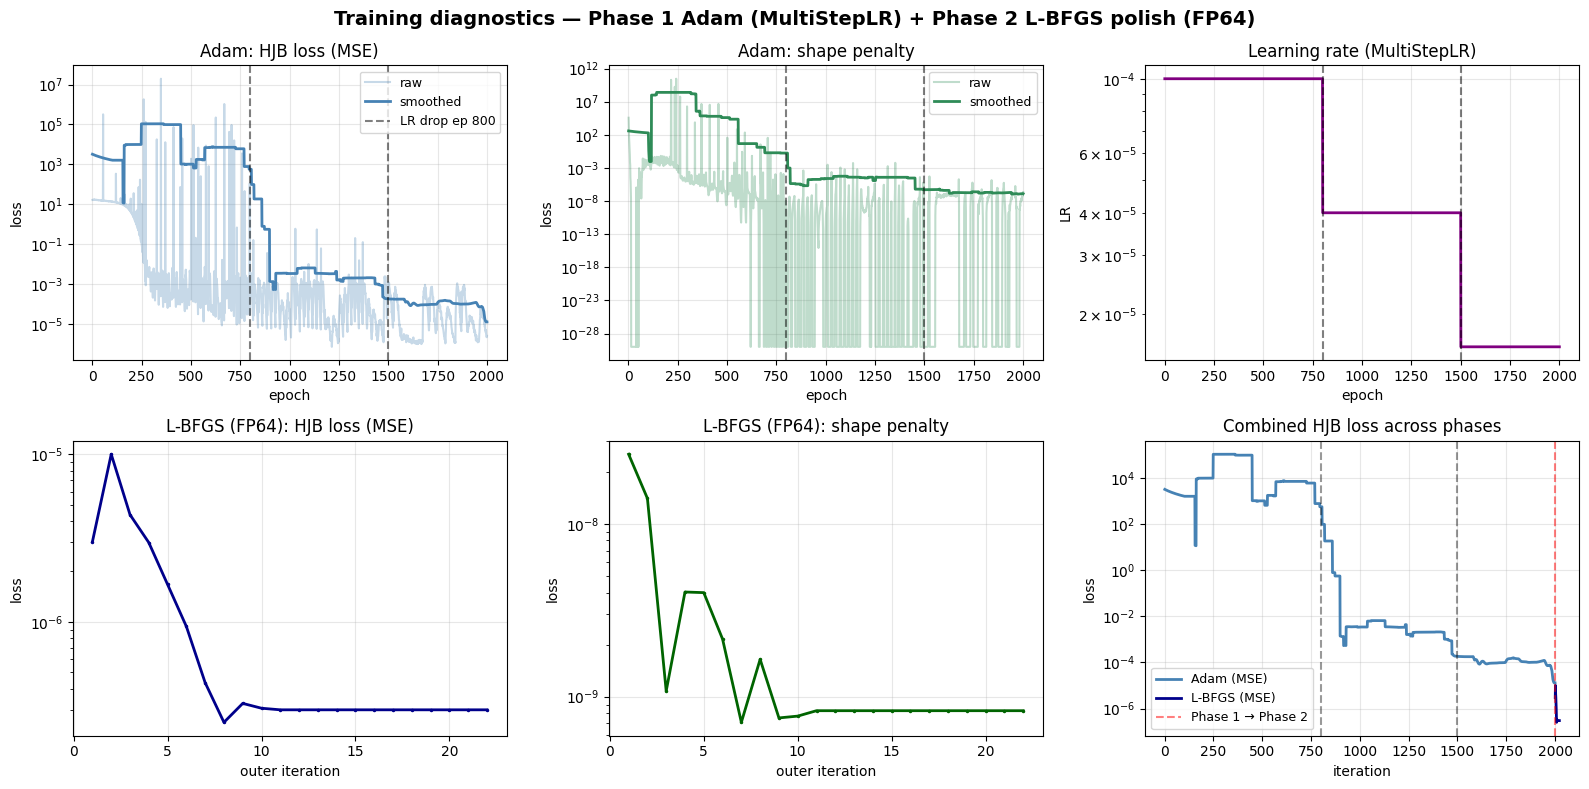


=== Final losses ===
  Phase 1 (Adam)   final HJB (MSE, smoothed)   = 1.2890e-05
  Phase 1 (Adam)   final shape (smoothed)      = 1.3057e-07
  Phase 2 (L-BFGS) final HJB (MSE, last iter)  = 2.9900e-07
  Phase 2 (L-BFGS) final shape                 = 8.2883e-10
  Phase 1 LR schedule: 1e-04 → 4.0e-05 → 1.6e-05
  Phase 1 shape weight (fixed)        = 10.0
  Phase 2 shape weight (fixed)        = 50.0


In [9]:
# =============================================================================
# Training diagnostics: Phase 1 (Adam) curves + Phase 2 (L-BFGS) curves.
# FOC-substituted residual, fixed shape-penalty weight.
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

def smooth(x, span=200):
    if len(x) <= span: return np.array(x)
    a = np.array(x, dtype=float)
    out = np.empty_like(a)
    for i in range(len(a)):
        lo = max(0, i - span // 2)
        hi = min(len(a), i + span // 2)
        out[i] = a[lo:hi].mean()
    return out

ep_adam = np.arange(1, len(hist_hjb) + 1)

# ---- Top row: Adam ----------------------------------------------------
axes[0, 0].semilogy(ep_adam, hist_hjb, alpha=0.3, color='steelblue', label='raw')
axes[0, 0].semilogy(ep_adam, smooth(hist_hjb), color='steelblue', lw=2, label='smoothed')
for ms in LR_MILESTONES:
    axes[0, 0].axvline(ms, color='k', linestyle='--', alpha=0.5,
                       label=f'LR drop ep {ms}' if ms == LR_MILESTONES[0] else None)
axes[0, 0].set_title('Adam: HJB loss (MSE)', fontsize=12)
axes[0, 0].set_xlabel('epoch'); axes[0, 0].set_ylabel('loss')
axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend(fontsize=9)

axes[0, 1].semilogy(ep_adam, np.array(hist_shape) + 1e-30, alpha=0.3, color='seagreen', label='raw')
axes[0, 1].semilogy(ep_adam, smooth(hist_shape) + 1e-30, color='seagreen', lw=2, label='smoothed')
for ms in LR_MILESTONES:
    axes[0, 1].axvline(ms, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Adam: shape penalty', fontsize=12)
axes[0, 1].set_xlabel('epoch'); axes[0, 1].set_ylabel('loss')
axes[0, 1].grid(True, alpha=0.3); axes[0, 1].legend(fontsize=9)

# LR schedule trace (computed from MultiStepLR)
lr_trace = np.full(len(hist_hjb), LR_INIT)
for ms_i, ms in enumerate(LR_MILESTONES):
    if ms < len(hist_hjb):
        lr_trace[ms:] *= LR_GAMMA

axes[0, 2].semilogy(ep_adam, lr_trace, color='purple', lw=2)
for ms in LR_MILESTONES:
    axes[0, 2].axvline(ms, color='k', linestyle='--', alpha=0.5)
axes[0, 2].set_title('Learning rate (MultiStepLR)', fontsize=12)
axes[0, 2].set_xlabel('epoch'); axes[0, 2].set_ylabel('LR')
axes[0, 2].grid(True, alpha=0.3)


# ---- Bottom row: L-BFGS ----------------------------------------------
ep_lbfgs = np.arange(1, len(hist_lbfgs_hjb) + 1)

axes[1, 0].semilogy(ep_lbfgs, hist_lbfgs_hjb, color='darkblue', lw=2, marker='.', ms=3)
axes[1, 0].set_title('L-BFGS (FP64): HJB loss (MSE)', fontsize=12)
axes[1, 0].set_xlabel('outer iteration'); axes[1, 0].set_ylabel('loss')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].semilogy(ep_lbfgs, np.array(hist_lbfgs_shape) + 1e-30,
                    color='darkgreen', lw=2, marker='.', ms=3)
axes[1, 1].set_title('L-BFGS (FP64): shape penalty', fontsize=12)
axes[1, 1].set_xlabel('outer iteration'); axes[1, 1].set_ylabel('loss')
axes[1, 1].grid(True, alpha=0.3)

# Combined HJB curve: Adam ramp + L-BFGS tail
ep_combined_lbfgs = np.arange(len(hist_hjb) + 1, len(hist_hjb) + 1 + len(hist_lbfgs_hjb))
axes[1, 2].semilogy(ep_adam, smooth(hist_hjb),       color='steelblue', lw=2, label='Adam (MSE)')
axes[1, 2].semilogy(ep_combined_lbfgs, hist_lbfgs_hjb, color='darkblue',  lw=2, label='L-BFGS (MSE)')
for ms in LR_MILESTONES:
    axes[1, 2].axvline(ms, color='k', linestyle='--', alpha=0.4)
axes[1, 2].axvline(len(hist_hjb), color='red', linestyle='--', alpha=0.5, label='Phase 1 → Phase 2')
axes[1, 2].set_title('Combined HJB loss across phases', fontsize=12)
axes[1, 2].set_xlabel('iteration'); axes[1, 2].set_ylabel('loss')
axes[1, 2].grid(True, alpha=0.3); axes[1, 2].legend(fontsize=9)


plt.suptitle('Training diagnostics — Phase 1 Adam (MultiStepLR) + Phase 2 L-BFGS polish (FP64)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_diagnostics_aiyagari.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary -----------------------------------------------
print()
print('=== Final losses ===')
print(f'  Phase 1 (Adam)   final HJB (MSE, smoothed)   = {smooth(hist_hjb)[-1]:.4e}')
print(f'  Phase 1 (Adam)   final shape (smoothed)      = {smooth(hist_shape)[-1]:.4e}')
print(f'  Phase 2 (L-BFGS) final HJB (MSE, last iter)  = {hist_lbfgs_hjb[-1]:.4e}')
print(f'  Phase 2 (L-BFGS) final shape                 = {hist_lbfgs_shape[-1]:.4e}')
print(f'  Phase 1 LR schedule: {LR_INIT:.0e} → '
      + ' → '.join([f'{LR_INIT * LR_GAMMA**(i+1):.1e}' for i in range(len(LR_MILESTONES))]))
print(f'  Phase 1 shape weight (fixed)        = {W_SHAPE}')
print(f'  Phase 2 shape weight (fixed)        = {LAM_SHAPE_LBFGS}')

---
## 8. Validation: Value Function on a Grid

Compare $\widehat V$ to $V^{\star}$ on a regular grid extending down to $y = 0$.

A specific diagnostic for the hard-BC trial solution: $\max_w |\widehat V(w, 0) - V_{BC}(w)|$ should be **machine-epsilon zero** - it is an integrity check that the trial solution is implemented correctly.


V_hat(1, 1)        = -0.462682
V*(1, 1)           = -0.464091    (closed form, post-hoc)
K_hat              = -0.001409            (level error)
|K_hat|            = 1.4094e-03     (level recovery error from HJB alone)

=== Hard-BC boundary check at y = Y_MIN ===
  max  |V_hat(w, Y_MIN) - V_Merton(w)| = 0.000e+00
  mean |V_hat(w, Y_MIN) - V_Merton(w)| = 0.000e+00
  Hard BC: V_hat(w, 0) = V_BC(w) exactly (modulo numerical precision).



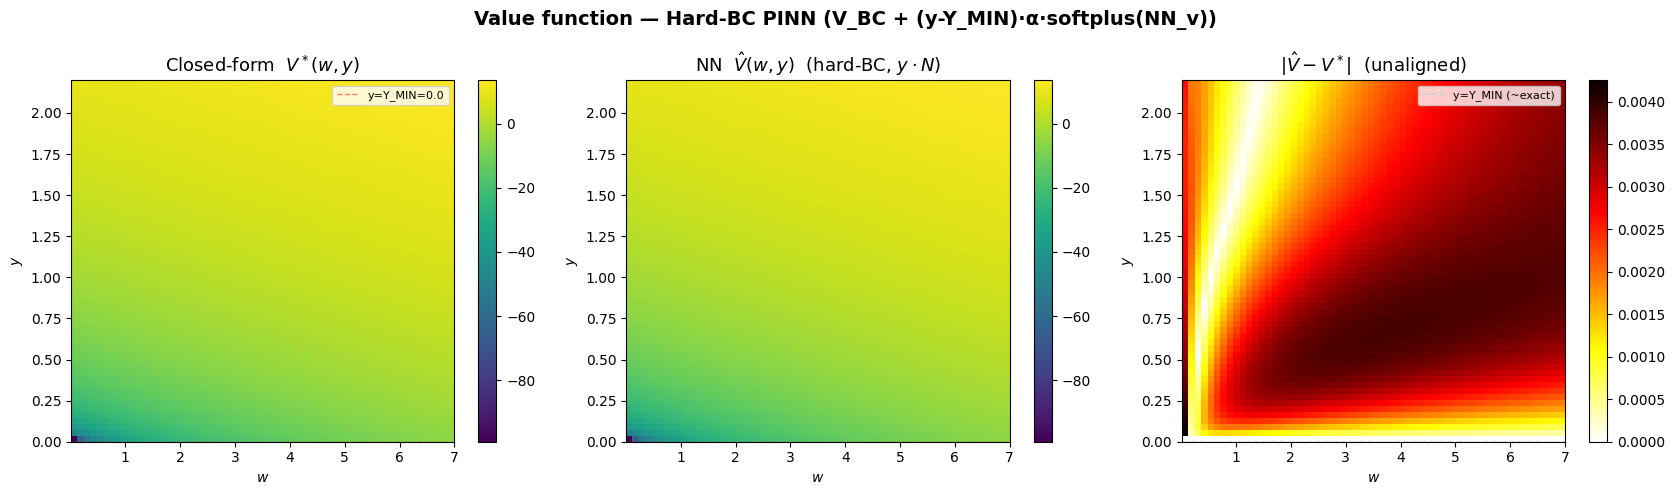

=== 2D grid errors ===
  Unaligned (honest, no level correction):
    Max absolute  = 0.004253
    Mean absolute = 0.002556
    Relative L2   = 0.0305%    ← primary metric



In [10]:
# =============================================================================
# 2D validation: V_hat vs V* on a grid that extends to y=Y_MIN.
#
# Hard-BC trial solution V_hat = V_BC(w) + (y - Y_MIN) · α · NN(w, y)
#   - Boundary at y=Y_MIN is exact by construction ((y-Y_MIN) = 0 → correction = 0)
#   - V_BC(w) = (1/δ) log(w) + K_cf is the analytical 1D Merton solution
#   - V*(w, y) closed form is used ONLY here, post-hoc, for validation
#   - K_hat is the level recovery error: small K_hat = HJB self-consistency
#     successfully pinned the level without explicit pin
# =============================================================================

net.eval()


# ---- Level diagnostic at reference point (1, 1) ----------------------
W_REF_PLOT = torch.tensor([1.0], device=device, dtype=next(net.parameters()).dtype)
Y_REF_PLOT = torch.tensor([1.0], device=device, dtype=next(net.parameters()).dtype)

with torch.no_grad():
    V_hat_at_11 = float(net(W_REF_PLOT, Y_REF_PLOT).cpu())

K_hat = V_true(1.0, 1.0) - V_hat_at_11           # level error: V* - V_hat
print(f'V_hat(1, 1)        = {V_hat_at_11:.6f}')
print(f'V*(1, 1)           = {V_true(1.0, 1.0):.6f}    (closed form, post-hoc)')
print(f'K_hat              = {K_hat:+.6f}            (level error)')
print(f'|K_hat|            = {abs(K_hat):.4e}     (level recovery error from HJB alone)')
print()


# ---- Hard-BC boundary check at y = Y_MIN -----------------------------
# At y=Y_MIN, (y - Y_MIN) = 0, so V_hat = V_BC(w) = V_Merton(w) EXACTLY.
print('=== Hard-BC boundary check at y = Y_MIN ===')
dt_net = next(net.parameters()).dtype
with torch.no_grad():
    w_b = torch.linspace(W_MIN + 0.05, W_MAX - 0.5, 20, device=device, dtype=dt_net)
    y_b = torch.full_like(w_b, Y_MIN)
    V_hat_b   = net(w_b, y_b)
    V_Merton_b = torch.log(w_b) / delta + B_merton
    err_b = (V_hat_b - V_Merton_b).abs()
print(f'  max  |V_hat(w, Y_MIN) - V_Merton(w)| = {err_b.max().item():.3e}')
print(f'  mean |V_hat(w, Y_MIN) - V_Merton(w)| = {err_b.mean().item():.3e}')
print(f'  Hard BC: V_hat(w, 0) = V_BC(w) exactly (modulo numerical precision).')
print()


# ---- 2D grid evaluation ----------------------------------------------
N_GRID = 60
w_grid = np.linspace(W_MIN, 7.0, N_GRID)
y_grid = np.linspace(Y_MIN, 2.2, N_GRID)
WW, YY = np.meshgrid(w_grid, y_grid)

V_cf_grid = V_true(WW, YY)

with torch.no_grad():
    wf = torch.tensor(WW.ravel(), dtype=dt_net, device=device)
    yf = torch.tensor(YY.ravel(), dtype=dt_net, device=device)
    V_nn_raw = net(wf, yf).cpu().numpy().reshape(N_GRID, N_GRID)

err_unaligned = np.abs(V_nn_raw - V_cf_grid)
err_aligned   = np.abs(V_nn_raw + K_hat - V_cf_grid)

rel_L2_raw     = np.sqrt(((V_nn_raw - V_cf_grid)**2).mean()) / np.sqrt((V_cf_grid**2).mean())
rel_L2_aligned = np.sqrt(((V_nn_raw + K_hat - V_cf_grid)**2).mean()) / np.sqrt((V_cf_grid**2).mean())


# ---- 2D heat maps ----------------------------------------------------
v_min = min(V_cf_grid.min(), V_nn_raw.min())
v_max = max(V_cf_grid.max(), V_nn_raw.max())

kw   = dict(origin='lower', aspect='auto',
            extent=[w_grid[0], w_grid[-1], y_grid[0], y_grid[-1]])
kw_v = dict(kw, cmap='viridis', vmin=v_min, vmax=v_max)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

im0 = axes[0].imshow(V_cf_grid, **kw_v)
axes[0].set_title('Closed-form  $V^*(w, y)$', fontsize=13)
axes[0].set_xlabel('$w$'); axes[0].set_ylabel('$y$')
axes[0].axhline(Y_MIN, color='red', alpha=0.5, lw=1.0, ls='--',
                label=f'y=Y_MIN={Y_MIN}')
axes[0].legend(fontsize=8, loc='upper right')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(V_nn_raw, **kw_v)
axes[1].set_title(r'NN  $\hat V(w, y)$  (hard-BC, $y \cdot N$)', fontsize=13)
axes[1].set_xlabel('$w$'); axes[1].set_ylabel('$y$')
axes[1].axhline(Y_MIN, color='red', alpha=0.5, lw=1.0, ls='--')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(err_unaligned, **kw, cmap='hot_r')
axes[2].set_title(r'$|\hat V - V^*|$  (unaligned)', fontsize=13)
axes[2].set_xlabel('$w$'); axes[2].set_ylabel('$y$')
axes[2].axhline(Y_MIN, color='lightblue', alpha=0.7, lw=1.2, ls='--',
                label=f'y=Y_MIN (~exact)')
axes[2].legend(fontsize=8, loc='upper right')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('Value function — Hard-BC PINN (V_BC + (y-Y_MIN)·α·softplus(NN_v))',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('value_function_hardBC_y_noSP.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary -----------------------------------------------
print('=== 2D grid errors ===')
print(f'  Unaligned (honest, no level correction):')
print(f'    Max absolute  = {err_unaligned.max():.6f}')
print(f'    Mean absolute = {err_unaligned.mean():.6f}')
print(f'    Relative L2   = {rel_L2_raw:.4%}    ← primary metric')
print()


---
## 9. Slices and Residual Map

Slices of $\widehat V$ vs. $V^{\star}$ at four wage levels including $y = 0$. The $y = 0$ curve coincides with $V_{BC}$ identically by construction; the other slices are the *learned* OLG correction.

The HJB residual heatmap (FOC-substituted) extends down to $y = 0$.


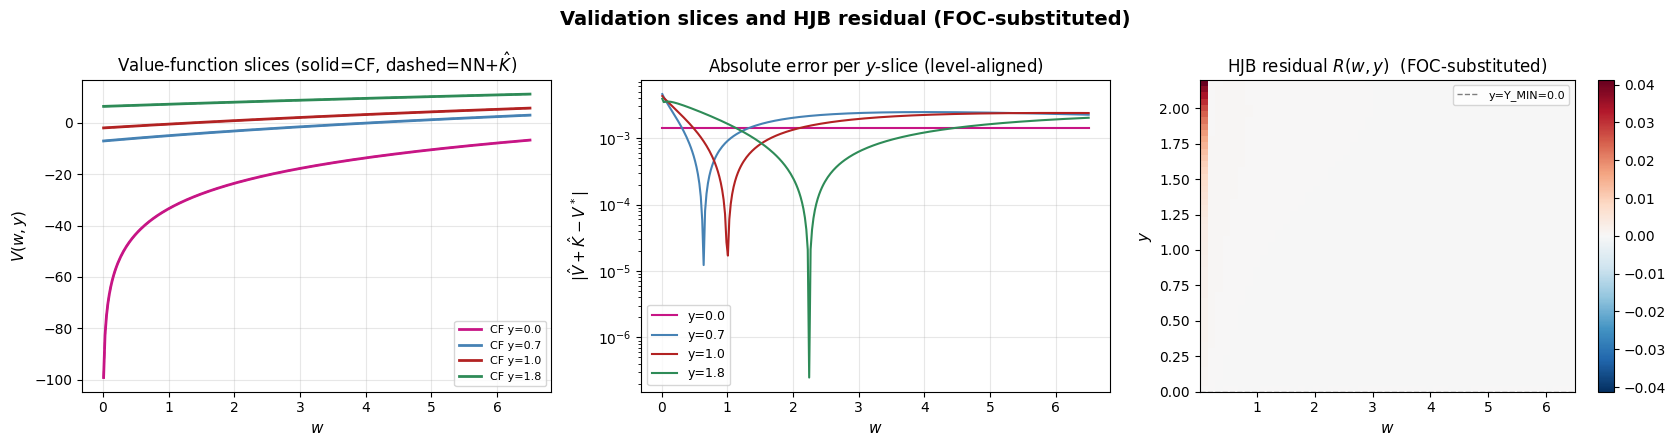

HJB residual (FOC-substituted): max|R|=4.1244e-02, mean|R|=3.3999e-04
(y=0.0 line: V_hat = V_BC = V_Merton exactly by hard BC; residual is Merton-PDE.)


In [11]:
# =============================================================================
# Slices of V_hat vs V* at several y values (level-aligned via K_hat),
# plus HJB residual heatmap (FOC-substituted).
# =============================================================================

dt_net = next(net.parameters()).dtype

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

y_slices = [Y_MIN, 0.7, 1.0, 1.8]
colors   = ['mediumvioletred', 'steelblue', 'firebrick', 'seagreen']
labels   = [f'y={Y_MIN}', 'y=0.7', 'y=1.0', 'y=1.8']
w_line   = np.linspace(W_MIN, 6.5, 300)

for y_s, col, lbl in zip(y_slices, colors, labels):
    V_cf_s = V_true(w_line, np.full_like(w_line, y_s))
    with torch.no_grad():
        w_t    = torch.tensor(w_line, dtype=dt_net, device=device)
        y_t    = torch.full_like(w_t, y_s)
        V_nn_s = net(w_t, y_t).cpu().numpy() + K_hat

    axes[0].plot(w_line, V_cf_s, '-',  color=col, lw=2,   label=f'CF {lbl}')
    axes[0].plot(w_line, V_nn_s, '--', color=col, lw=1.3)
    err = np.abs(V_nn_s - V_cf_s) + 1e-16
    axes[1].semilogy(w_line, err, color=col, lw=1.5, label=lbl)

axes[0].set_xlabel('$w$', fontsize=11)
axes[0].set_ylabel('$V(w, y)$', fontsize=11)
axes[0].set_title('Value-function slices (solid=CF, dashed=NN+$\\hat K$)', fontsize=12)
axes[0].legend(fontsize=8, ncol=1, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('$w$', fontsize=11)
axes[1].set_ylabel(r'$|\hat V + \hat K - V^*|$', fontsize=11)
axes[1].set_title('Absolute error per $y$-slice (level-aligned)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)


# ── HJB residual heatmap (FOC-substituted, matches training) ───────────
N_RES = 50
w_r = np.linspace(W_MIN, 6.5, N_RES)
y_r = np.linspace(Y_MIN, 2.2, N_RES)
WW_r, YY_r = np.meshgrid(w_r, y_r)

w_rt = torch.tensor(WW_r.ravel(), dtype=dt_net, device=device, requires_grad=True)
y_rt = torch.tensor(YY_r.ravel(), dtype=dt_net, device=device, requires_grad=True)

V_r, Vw_r, Vy_r, Vww_r, Vwy_r, Vyy_r, w_rt, y_rt = compute_all_derivatives(net, w_rt, y_rt)

# FOC substitution (matches Phase 1 / Phase 2 training closure)
safe_Vw  = Vw_r.clamp_min(1e-4)
safe_Vww = Vww_r.clamp_max(-1e-3)
c_FOC  = 1.0 / safe_Vw
pi_FOC = -(Vw_r * (mu_S - r_cf) + Vwy_r * sig_S * sig_Y * y_rt) / (safe_Vww * sig_S ** 2)

utility = torch.log(c_FOC.clamp(min=1e-8))
T2 = -(rho + nu) * V_r
T3 = Vw_r * ((r_cf + nu) * w_rt + pi_FOC * (mu_S - r_cf) + omega * y_rt - c_FOC)
T4 = Vy_r * mu_Y * y_rt
T5 = 0.5 * Vww_r * pi_FOC ** 2 * sig_S ** 2
T6 = Vwy_r * pi_FOC * sig_S * sig_Y * y_rt
T7 = 0.5 * Vyy_r * sig_Y ** 2 * y_rt ** 2
res = (utility + T2 + T3 + T4 + T5 + T6 + T7)
res_map = res.detach().cpu().numpy().reshape(N_RES, N_RES)

lim = max(abs(res_map.min()), abs(res_map.max()), 1e-10)
im  = axes[2].imshow(res_map, origin='lower', aspect='auto', cmap='RdBu_r',
                     vmin=-lim, vmax=lim,
                     extent=[w_r[0], w_r[-1], y_r[0], y_r[-1]])
axes[2].set_xlabel('$w$', fontsize=11)
axes[2].set_ylabel('$y$', fontsize=11)
axes[2].set_title(r'HJB residual $R(w, y)$  (FOC-substituted)', fontsize=12)
axes[2].axhline(Y_MIN, color='black', alpha=0.5, lw=1.0, ls='--',
                label=f'y=Y_MIN={Y_MIN}')
axes[2].legend(fontsize=8, loc='upper right')
plt.colorbar(im, ax=axes[2])

plt.suptitle('Validation slices and HJB residual (FOC-substituted)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('validation_slices_aiyagari.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'HJB residual (FOC-substituted): max|R|={np.abs(res_map).max():.4e}, '
      f'mean|R|={np.abs(res_map).mean():.4e}')
print(f'(y={Y_MIN} line: V_hat = V_BC = V_Merton exactly by hard BC; residual is Merton-PDE.)')

---
## 10. Optimal Policies

Optimal controls $c^{\star}$ and $\pi^{\star}$ recovered from $\widehat V$ via the FOCs. As a special case, at $y = 0$ (log-utility Merton-with-mortality limit):

- $c^{\star}(w, 0) = \delta\,w$ (log-utility Merton consumption rule).
- $\pi^{\star}(w, 0) = \dfrac{\mu_S - r}{\sigma_S^2}\,w$ (log-utility Merton portfolio rule).

Both are exact by construction. Away from $y = 0$ they are the learned OLG policies.


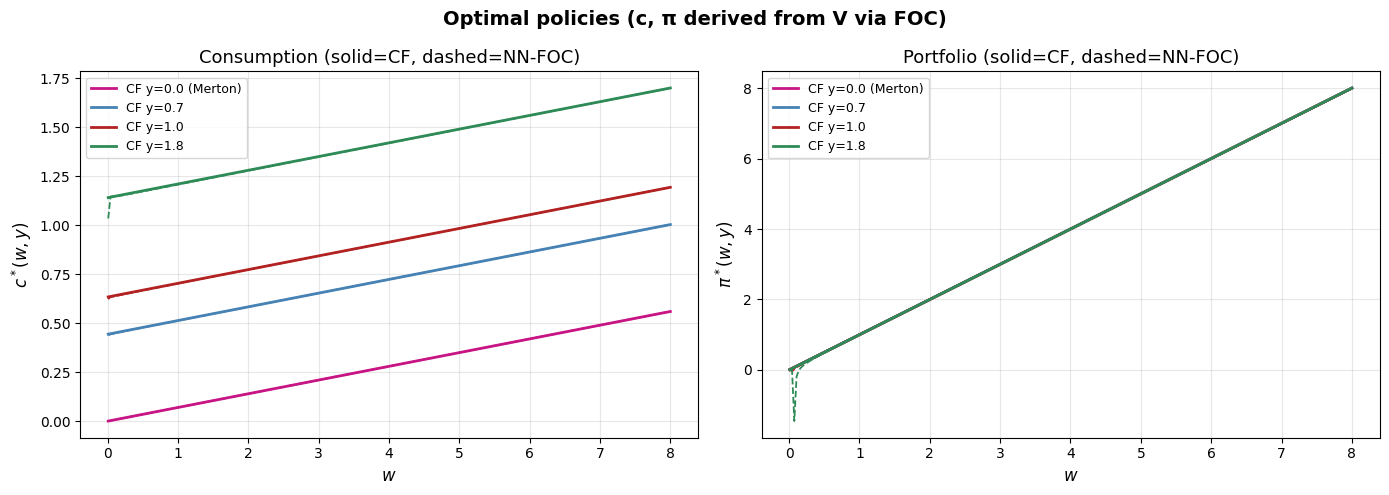


=== Policy errors (FOC-derived from V) ===
At y=0.0 (V_hat = V_BC = V_Merton by hard BC; FOC at y=0: c = δw, π = (μ-r)/σ²·w):
  max |c_FOC - c*|       = 0.00000
  max |π_FOC - π*|       = 0.00000
At y=1.0 (interior — learned policies):
  max |c_FOC - c*|       = 0.01141
  max |π_FOC - π*|       = 0.08679
At y=1.0, restricted to w > 1:
  max |c_FOC - c*|       = 0.00100
  max |π_FOC - π*|       = 0.00147


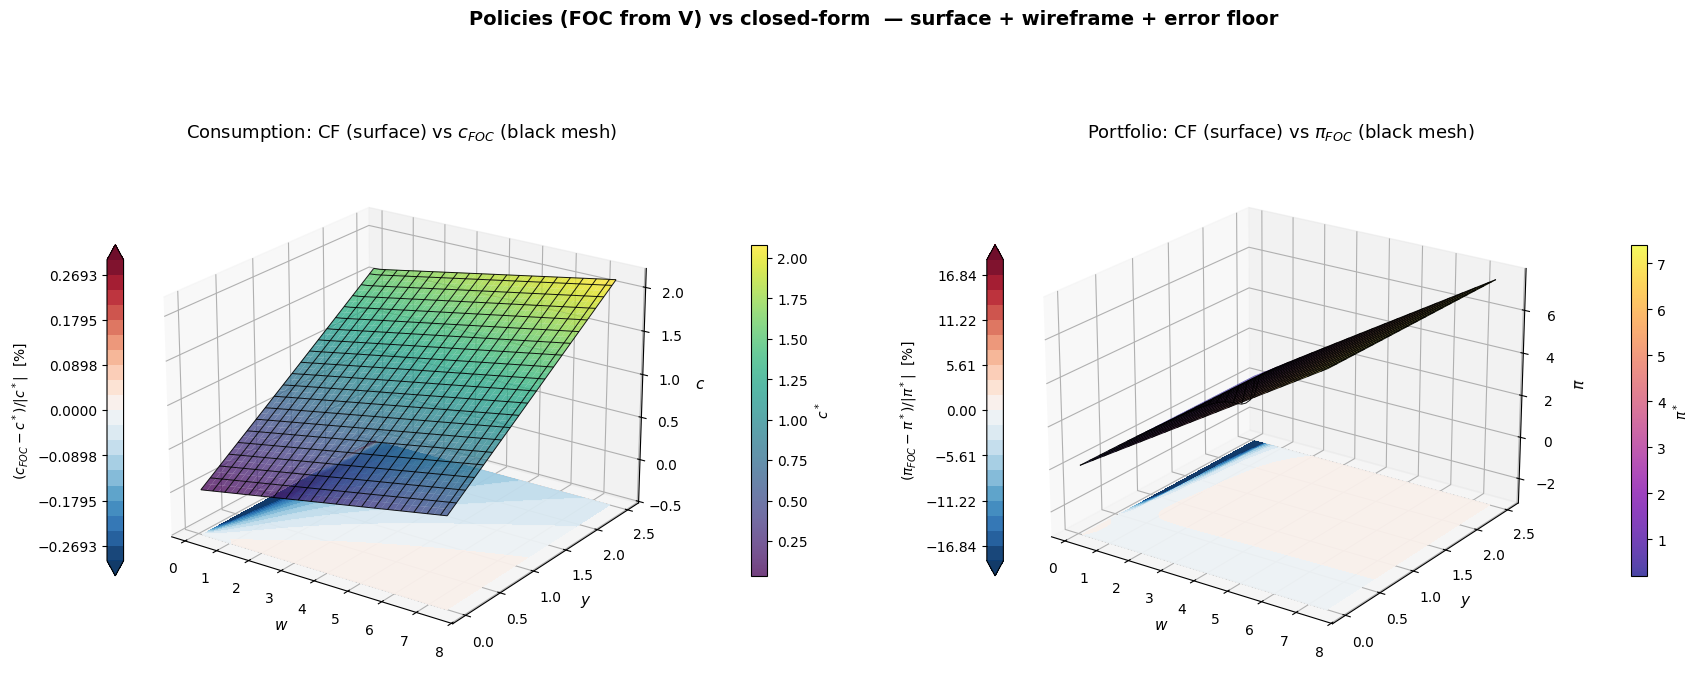


=== 3D policy agreement (full grid, FOC-derived from V) ===
  Consumption:  max err = 0.0044   mean err = 0.0008   rel L2 = 0.1100%
  Portfolio:    max err = 1.1541   mean err = 0.0096   rel L2 = 1.5980%
  Consumption:  max |%diff| = 0.51%   mean |%diff| = 0.07%
  Portfolio:    max |%diff| = 1049.18%   mean |%diff| = 6.13%


In [12]:
# =============================================================================
# Optimal policies c* and π* — FOC-derived from V_w, V_ww.
# c_FOC = 1/V_w (log utility),  π_FOC from analytical π-FOC.
# =============================================================================

PI_MERTON_COEF = (mu_S - r_cf) / sig_S**2

dt_net = next(net.parameters()).dtype
net.eval()


def policies_FOC(w, y):
    """Compute (c, π) at points (w, y) via FOC substitution from V's derivatives.
    Uses the same safeguards as the training closure.
    """
    w_t = torch.as_tensor(w, dtype=dt_net, device=device).clone().requires_grad_(True)
    y_t = torch.as_tensor(y, dtype=dt_net, device=device).clone().requires_grad_(True)
    _, Vw, _, Vww, Vwy, _, w_g, y_g = compute_all_derivatives(net, w_t, y_t)
    safe_Vw  = Vw.clamp_min(1e-4)
    safe_Vww = Vww.clamp_max(-1e-3)
    c_FOC  = 1.0 / safe_Vw
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_g) / (safe_Vww * sig_S ** 2)
    return c_FOC.detach().cpu().numpy(), pi_FOC.detach().cpu().numpy()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_slices = [Y_MIN, 0.7, 1.0, 1.8]
colors   = ['mediumvioletred', 'steelblue', 'firebrick', 'seagreen']
labels   = [f'y={Y_MIN} (Merton)', 'y=0.7', 'y=1.0', 'y=1.8']
w_line   = np.linspace(W_MIN, W_MAX, 250)

for y_s, col, lbl in zip(y_slices, colors, labels):
    c_cf  = delta * (w_line + phi_e * y_s)
    pi_cf = PI_MERTON_COEF * (w_line + phi_e * y_s) - (phi_e * sig_Y / sig_S) * y_s

    # FOC-derived policies from network's V
    c_nn, pi_nn = policies_FOC(w_line, np.full_like(w_line, y_s))

    axes[0].plot(w_line, c_cf,  '-',  color=col, lw=2,   label=f'CF {lbl}')
    axes[0].plot(w_line, c_nn,  '--', color=col, lw=1.3)
    axes[1].plot(w_line, pi_cf, '-',  color=col, lw=2,   label=f'CF {lbl}')
    axes[1].plot(w_line, pi_nn, '--', color=col, lw=1.3)

for ax, ylabel, title in zip(
    axes,
    ['$c^*(w, y)$', r'$\pi^*(w, y)$'],
    ['Consumption (solid=CF, dashed=NN-FOC)',
     'Portfolio (solid=CF, dashed=NN-FOC)']
):
    ax.set_xlabel('$w$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Optimal policies (c, π derived from V via FOC)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('policies_LOG.png', dpi=150, bbox_inches='tight')
plt.show()


print()
print('=== Policy errors (FOC-derived from V) ===')

# y = Y_MIN
y_0 = Y_MIN
c_nn_0, pi_nn_0 = policies_FOC(w_line, np.full_like(w_line, y_0))
c_cf_0  = delta * (w_line + phi_e * y_0)
pi_cf_0 = PI_MERTON_COEF * (w_line + phi_e * y_0) - (phi_e * sig_Y / sig_S) * y_0
print(f'At y={Y_MIN} (V_hat = V_BC = V_Merton by hard BC; '
      f'FOC at y=0: c = δw, π = (μ-r)/σ²·w):')
print(f'  max |c_FOC - c*|       = {np.abs(c_nn_0 - c_cf_0).max():.5f}')
print(f'  max |π_FOC - π*|       = {np.abs(pi_nn_0 - pi_cf_0).max():.5f}')

# y = 1.0
y_1 = 1.0
c_nn_1, pi_nn_1 = policies_FOC(w_line, np.full_like(w_line, y_1))
c_cf_1  = delta * (w_line + phi_e * y_1)
pi_cf_1 = PI_MERTON_COEF * (w_line + phi_e * y_1) - (phi_e * sig_Y / sig_S) * y_1
print(f'At y=1.0 (interior — learned policies):')
print(f'  max |c_FOC - c*|       = {np.abs(c_nn_1 - c_cf_1).max():.5f}')
print(f'  max |π_FOC - π*|       = {np.abs(pi_nn_1 - pi_cf_1).max():.5f}')

mask = w_line > 1.0
print(f'At y=1.0, restricted to w > 1:')
print(f'  max |c_FOC - c*|       = {np.abs(c_nn_1[mask] - c_cf_1[mask]).max():.5f}')
print(f'  max |π_FOC - π*|       = {np.abs(pi_nn_1[mask] - pi_cf_1[mask]).max():.5f}')


# =============================================================================
# 3D policy "cube" visualization:
#   Top: CF as filled colored surface, NN-FOC as black wireframe
#   Bottom (floor of 3D box): 2D heatmap of relative % error projected at z=z_floor
# =============================================================================

from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

N_3D = 40
w_3d = np.linspace(W_MIN + 0.1, W_MAX - 0.5, N_3D)
y_3d = np.linspace(Y_MIN, Y_MAX, N_3D)
WW_3d, YY_3d = np.meshgrid(w_3d, y_3d)

C_cf_3d  = delta * (WW_3d + phi_e * YY_3d)
PI_cf_3d = PI_MERTON_COEF * (WW_3d + phi_e * YY_3d) - (phi_e * sig_Y / sig_S) * YY_3d

# NN policies from FOC on the grid
c_3d_arr, pi_3d_arr = policies_FOC(WW_3d.ravel(), YY_3d.ravel())
C_nn_3d  = c_3d_arr.reshape(N_3D, N_3D)
PI_nn_3d = pi_3d_arr.reshape(N_3D, N_3D)

# Percent differences (signed)
eps_c  = max(1e-6, 1e-3 * np.abs(C_cf_3d).max())
eps_pi = max(1e-6, 1e-3 * np.abs(PI_cf_3d).max())
PD_c   = 100.0 * (C_nn_3d  - C_cf_3d)  / np.maximum(np.abs(C_cf_3d),  eps_c)
PD_pi  = 100.0 * (PI_nn_3d - PI_cf_3d) / np.maximum(np.abs(PI_cf_3d), eps_pi)

vlim_c  = np.percentile(np.abs(PD_c),  98)
vlim_pi = np.percentile(np.abs(PD_pi), 98)


def plot_cube(ax, WW, YY, CF, NN, PD, vlim_pd, cmap_surf, title, zlabel,
              colorbar_label='% deviation'):
    z_top    = max(CF.max(), NN.max())
    z_bottom = min(CF.min(), NN.min())
    z_floor  = z_bottom - 0.25 * (z_top - z_bottom)

    surf = ax.plot_surface(WW, YY, CF, cmap=cmap_surf,
                           edgecolor='none', alpha=0.75, antialiased=True)
    ax.plot_wireframe(WW, YY, NN, color='black', linewidth=0.7,
                      rstride=2, cstride=2, alpha=0.9)
    pd_levels = np.linspace(-vlim_pd, +vlim_pd, 21)
    cf_floor = ax.contourf(WW, YY, PD, levels=pd_levels, cmap='RdBu_r',
                            offset=z_floor, alpha=0.95, extend='both')

    ax.set_zlim(z_floor, z_top + 0.05 * (z_top - z_bottom))
    ax.set_xlabel('$w$', fontsize=11)
    ax.set_ylabel('$y$', fontsize=11)
    ax.set_zlabel(zlabel, fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.view_init(elev=22, azim=-55)
    return surf, cf_floor


fig = plt.figure(figsize=(18, 8))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf_c, cf_c = plot_cube(ax1, WW_3d, YY_3d,
                          C_cf_3d, C_nn_3d, PD_c, vlim_c,
                          cmap_surf='viridis',
                          title=r'Consumption: CF (surface) vs $c_{FOC}$ (black mesh)',
                          zlabel='$c$')
cbar1_top = fig.colorbar(surf_c, ax=ax1, shrink=0.45, pad=0.10, location='right')
cbar1_top.set_label(r'$c^*$', fontsize=10)
cbar1_bot = fig.colorbar(cf_c, ax=ax1, shrink=0.45, pad=0.02, location='left')
cbar1_bot.set_label(r'$(c_{FOC} - c^*)/|c^*|$  [%]', fontsize=10)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf_pi, cf_pi = plot_cube(ax2, WW_3d, YY_3d,
                            PI_cf_3d, PI_nn_3d, PD_pi, vlim_pi,
                            cmap_surf='plasma',
                            title=r'Portfolio: CF (surface) vs $\pi_{FOC}$ (black mesh)',
                            zlabel=r'$\pi$')
cbar2_top = fig.colorbar(surf_pi, ax=ax2, shrink=0.45, pad=0.10, location='right')
cbar2_top.set_label(r'$\pi^*$', fontsize=10)
cbar2_bot = fig.colorbar(cf_pi, ax=ax2, shrink=0.45, pad=0.02, location='left')
cbar2_bot.set_label(r'$(\pi_{FOC} - \pi^*)/|\pi^*|$  [%]', fontsize=10)

plt.suptitle('Policies (FOC from V) vs closed-form  — surface + wireframe + error floor',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('policies_cube_LOG.png', dpi=150, bbox_inches='tight')
plt.show()


# =============================================================================
# Numerical summary
# =============================================================================
print()
print('=== 3D policy agreement (full grid, FOC-derived from V) ===')
err_c  = np.abs(C_nn_3d  - C_cf_3d)
err_pi = np.abs(PI_nn_3d - PI_cf_3d)
rel_c  = np.sqrt((err_c**2).mean()) / np.sqrt((C_cf_3d**2).mean())
rel_pi = np.sqrt((err_pi**2).mean()) / np.sqrt((PI_cf_3d**2).mean())
print(f'  Consumption:  max err = {err_c.max():.4f}   mean err = {err_c.mean():.4f}   rel L2 = {rel_c:.4%}')
print(f'  Portfolio:    max err = {err_pi.max():.4f}   mean err = {err_pi.mean():.4f}   rel L2 = {rel_pi:.4%}')
print(f'  Consumption:  max |%diff| = {np.abs(PD_c).max():.2f}%   mean |%diff| = {np.abs(PD_c).mean():.2f}%')
print(f'  Portfolio:    max |%diff| = {np.abs(PD_pi).max():.2f}%   mean |%diff| = {np.abs(PD_pi).mean():.2f}%')

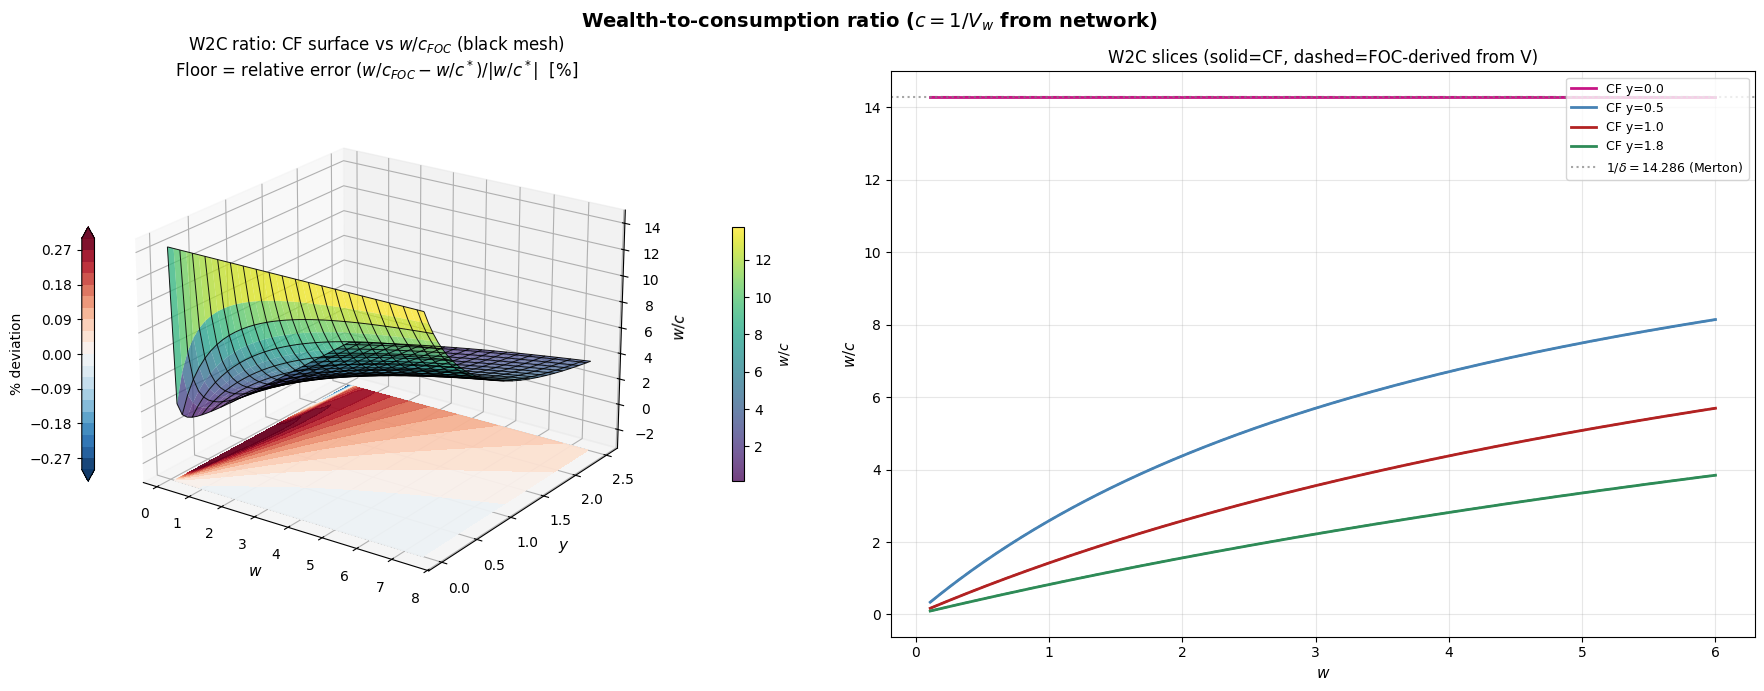


=== W2C ratio agreement (full grid, FOC-derived from V) ===
  Max abs error          = 0.0023
  Mean abs error         = 0.0013
  Max relative error     = 0.5163%
  Mean relative error    = 0.0720%
  Relative L2            = 0.0265%

  Max |%diff| (signed)   = 0.52%
  Mean |%diff| (signed)  = 0.07%

=== At y=Y_MIN=0.0 (Merton classical limit) ===
  Expected w/c           = 1/δ = 14.28571
  Mean w/c (FOC, y=0)    = 14.28571
  Max |w/c - 1/δ| at y=0 = 0.00000


In [13]:
# =============================================================================
# Wealth-to-consumption ratio diagnostic.
# c is derived from V via FOC (c = 1/V_w).
# =============================================================================

from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

dt_net = next(net.parameters()).dtype
net.eval()


def c_FOC_array(w, y):
    """Compute c = 1/V_w via FOC from network's autograd, with clamp safeguards."""
    w_t = torch.as_tensor(w, dtype=dt_net, device=device).clone().requires_grad_(True)
    y_t = torch.as_tensor(y, dtype=dt_net, device=device).clone().requires_grad_(True)
    _, Vw, _, _, _, _, _, _ = compute_all_derivatives(net, w_t, y_t)
    safe_Vw = Vw.clamp_min(1e-4)
    c = 1.0 / safe_Vw
    return c.detach().cpu().numpy()


N_2D = 40
w_2d = np.linspace(W_MIN + 0.1, W_MAX - 0.5, N_2D)
y_2d = np.linspace(Y_MIN, Y_MAX, N_2D)
WW_2d, YY_2d = np.meshgrid(w_2d, y_2d)

C_cf_2d = delta * (WW_2d + phi_e * YY_2d)
W2C_cf  = WW_2d / C_cf_2d

# c from V's FOC, not from forward_policies
C_nn_2d = c_FOC_array(WW_2d.ravel(), YY_2d.ravel()).reshape(N_2D, N_2D)
W2C_nn  = WW_2d / C_nn_2d

# Percent difference
PD_w2c = 100.0 * (W2C_nn - W2C_cf) / np.maximum(np.abs(W2C_cf), 1e-6)
vlim_w2c = np.percentile(np.abs(PD_w2c), 98)


# =============================================================================
# Figure: 3D cube + slices side-by-side
# =============================================================================
fig = plt.figure(figsize=(18, 7))

# ─── Left: 3D cube ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

z_top    = max(W2C_cf.max(), W2C_nn.max())
z_bottom = min(W2C_cf.min(), W2C_nn.min())
z_floor  = z_bottom - 0.25 * (z_top - z_bottom)

surf = ax1.plot_surface(WW_2d, YY_2d, W2C_cf, cmap='viridis',
                         edgecolor='none', alpha=0.75, antialiased=True)
ax1.plot_wireframe(WW_2d, YY_2d, W2C_nn, color='black', linewidth=0.7,
                    rstride=2, cstride=2, alpha=0.9)

pd_levels = np.linspace(-vlim_w2c, +vlim_w2c, 21)
cf_floor = ax1.contourf(WW_2d, YY_2d, PD_w2c, levels=pd_levels, cmap='RdBu_r',
                         offset=z_floor, alpha=0.95, extend='both')

ax1.set_zlim(z_floor, z_top + 0.05 * (z_top - z_bottom))
ax1.set_xlabel('$w$', fontsize=11)
ax1.set_ylabel('$y$', fontsize=11)
ax1.set_zlabel('$w/c$', fontsize=11)
ax1.set_title(r'W2C ratio: CF surface vs $w/c_{FOC}$ (black mesh)' '\n'
              r'Floor = relative error $(w/c_{FOC} - w/c^*)/|w/c^*|$  [%]',
              fontsize=12)
ax1.view_init(elev=22, azim=-55)

cbar1_top = fig.colorbar(surf, ax=ax1, shrink=0.45, pad=0.10, location='right')
cbar1_top.set_label(r'$w/c$', fontsize=10)
cbar1_bot = fig.colorbar(cf_floor, ax=ax1, shrink=0.45, pad=0.02, location='left')
cbar1_bot.set_label(r'% deviation', fontsize=10)

# ─── Right: 1D slices ──────────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)

y_slice_vals = [0.0, 0.5, 1.0, 1.8]
colors_slc   = ['mediumvioletred', 'steelblue', 'firebrick', 'seagreen']
w_line_slc   = np.linspace(W_MIN + 0.1, 6.0, 250)

for y_s, col in zip(y_slice_vals, colors_slc):
    c_cf_s   = delta * (w_line_slc + phi_e * y_s)
    w2c_cf_s = w_line_slc / c_cf_s

    # c from V via FOC
    c_nn_s   = c_FOC_array(w_line_slc, np.full_like(w_line_slc, y_s))
    w2c_nn_s = w_line_slc / c_nn_s

    ax2.plot(w_line_slc, w2c_cf_s, '-',  color=col, lw=2,   label=f'CF y={y_s}')
    ax2.plot(w_line_slc, w2c_nn_s, '--', color=col, lw=1.5)

ax2.axhline(1.0/delta, color='gray', linestyle=':', alpha=0.7,
            label=f'$1/\\delta = {1.0/delta:.3f}$ (Merton)')
ax2.set_xlabel('$w$', fontsize=11)
ax2.set_ylabel('$w/c$', fontsize=11)
ax2.set_title('W2C slices (solid=CF, dashed=FOC-derived from V)', fontsize=12)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle(r'Wealth-to-consumption ratio ($c = 1/V_w$ from network)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('w2c_cube_LOG.png', dpi=150, bbox_inches='tight')
plt.show()


# =============================================================================
# Numerical summary
# =============================================================================
print()
print('=== W2C ratio agreement (full grid, FOC-derived from V) ===')
err_w2c     = np.abs(W2C_nn - W2C_cf)
rel_err_w2c = np.abs(W2C_nn - W2C_cf) / W2C_cf
rel_L2_w2c  = np.sqrt(((W2C_nn - W2C_cf)**2).mean()) / np.sqrt((W2C_cf**2).mean())
print(f'  Max abs error          = {err_w2c.max():.4f}')
print(f'  Mean abs error         = {err_w2c.mean():.4f}')
print(f'  Max relative error     = {rel_err_w2c.max():.4%}')
print(f'  Mean relative error    = {rel_err_w2c.mean():.4%}')
print(f'  Relative L2            = {rel_L2_w2c:.4%}')
print()
print(f'  Max |%diff| (signed)   = {np.abs(PD_w2c).max():.2f}%')
print(f'  Mean |%diff| (signed)  = {np.abs(PD_w2c).mean():.2f}%')

print()
print(f'=== At y=Y_MIN={Y_MIN} (Merton classical limit) ===')
print(f'  Expected w/c           = 1/δ = {1.0/delta:.5f}')
print(f'  Mean w/c (FOC, y=0)    = {W2C_nn[0, :].mean():.5f}')
print(f'  Max |w/c - 1/δ| at y=0 = {np.abs(W2C_nn[0, :] - 1.0/delta).max():.5f}')

---
## 11. Summary Table

Quantitative comparison of $\widehat V$ and recovered policies against the closed form.


In [14]:
# =============================================================================
# Final summary table.
# c is derived from V via the log-utility FOC c = 1/V_w.
# =============================================================================

dt_net = next(net.parameters()).dtype
res_flat = res_map.ravel()

# phi diagnostic: (w + phi_e·y) / c, evaluated at (1, 1) using FOC-derived c
w_ref_t = torch.tensor([1.0], dtype=dt_net, device=device, requires_grad=True)
y_ref_t = torch.tensor([1.0], dtype=dt_net, device=device, requires_grad=True)
_, Vw_ref, _, _, _, _, _, _ = compute_all_derivatives(net, w_ref_t, y_ref_t)
c_ref   = (1.0 / Vw_ref.clamp_min(1e-4)).item()
what_r  = 1.0 + phi_e * 1.0
phi_nn_r = what_r / c_ref

with torch.no_grad():
    w_b = torch.linspace(W_MIN + 0.05, W_MAX - 0.5, 50, device=device, dtype=dt_net)
    y_b = torch.full_like(w_b, Y_MIN)
    V_hat_b    = net(w_b, y_b)
    V_Merton_b = torch.log(w_b) / delta + B_merton
    bdry_err   = float((V_hat_b - V_Merton_b).abs().max().cpu())

with torch.no_grad():
    V_hat_at_11 = float(net(
        torch.tensor([1.0], dtype=dt_net, device=device),
        torch.tensor([1.0], dtype=dt_net, device=device)
    ).cpu())
K_hat_val = V_true(1.0, 1.0) - V_hat_at_11

err_grid_unaligned = np.abs(V_nn_raw - V_cf_grid)
rel_L2_unaligned   = np.sqrt(((V_nn_raw - V_cf_grid)**2).mean()) / np.sqrt((V_cf_grid**2).mean())
err_grid_aligned   = np.abs(V_nn_raw + K_hat_val - V_cf_grid)
rel_L2_aligned     = np.sqrt(((V_nn_raw + K_hat_val - V_cf_grid)**2).mean()) / np.sqrt((V_cf_grid**2).mean())


print('=' * 75)
print('  HARD-BC LOG-UTILITY HJB-PINN: SUMMARY TABLE')
print('=' * 75)
print(f'  {"Quantity":<40} {"Closed form":>12}    {"Hard-BC PINN":>14}')
print('-' * 75)
print(f'  {"phi  ((w + phi_e y)/c_FOC) at (1,1)":<40} {phi_cf:>12.5f}    {phi_nn_r:>14.5f}')
print(f'  {"c_FOC(1,1) recovered":<40} {1.0/(delta*(1.0+phi_e)):>12.5f}    {c_ref:>14.5f}')
print(f'  {"V_hat(1, 1) recovered":<40} {V_true(1.0, 1.0):>12.5f}    {V_hat_at_11:>14.5f}')
print(f'  {"K_hat = V*(1,1) - V_hat(1,1)":<40} {0.0:>12.5f}    {K_hat_val:>14.5f}')
print('-' * 75)
print(f'  {"Rel L2 (UNALIGNED — honest)":<40} {"---":>12}    {rel_L2_unaligned:>14.4%}')
print(f'  {"Rel L2 (aligned, K_hat removed)":<40} {"---":>12}    {rel_L2_aligned:>14.4%}')
print(f'  {"Max abs V error (unaligned)":<40} {"---":>12}    {err_grid_unaligned.max():>14.6f}')
print(f'  {"Mean abs V error (unaligned)":<40} {"---":>12}    {err_grid_unaligned.mean():>14.6f}')
print('-' * 75)
print(f'  {"HJB residual mean |R|":<40} {0.0:>12.0e}    {np.abs(res_flat).mean():>14.4e}')
print(f'  {"HJB residual max  |R|":<40} {0.0:>12.0e}    {np.abs(res_flat).max():>14.4e}')
print(f'  {"Implied phi rel. error":<40} {"---":>12}    {abs(phi_nn_r-phi_cf)/phi_cf:>14.4%}')
print(f'  {f"|V_hat(w,Y_MIN) - V_Merton(w)| max":<40} {0.0:>12.0e}    {bdry_err:>14.4e}')
print('=' * 75)
print()
print('=== What this notebook used during training ===')
print('  Inputs : delta, r_cf, mu_S, sig_S, mu_Y, sig_Y, omega, K_cf (log-limit Merton constant)')
print('  Did NOT use: V_true(w,y), phi_e, V*(1,1), c* — none of these appear in any loss.')
print()
print('=== Key methodological claims ===')
print(f'  1. Hard BC at y=Y_MIN built into architecture:      SATISFIED')
print(f'     V_hat(w, Y_MIN) = V_BC(w) exactly (max err = {bdry_err:.2e})')
print(f'  2. No level pin during training:                    HJB recovered K_hat = {K_hat_val:.4f}')
print(f'  3. Trial-solution ansatz:                           V_hat = (1/δ)·log(w + (y-Y_MIN)·softplus(NN)) + K_cf')
print(f'  4. FOC substitution in HJB residual:                c = 1/V_w,  π from analytical π-FOC')
print(f'  5. Fixed loss weights:                              HJB:shape = 1:10 (Phase 1), 1:50 (Phase 2)')
print(f'  6. Optimiser pipeline:                              Phase 1 Adam (MultiStepLR, FP32, from random init) → Phase 2 L-BFGS (FP64 polish)')

  HARD-BC LOG-UTILITY HJB-PINN: SUMMARY TABLE
  Quantity                                  Closed form      Hard-BC PINN
---------------------------------------------------------------------------
  phi  ((w + phi_e y)/c_FOC) at (1,1)          14.28571          14.30605
  c_FOC(1,1) recovered                          1.42111           0.70268
  V_hat(1, 1) recovered                        -0.46409          -0.46268
  K_hat = V*(1,1) - V_hat(1,1)                  0.00000          -0.00141
---------------------------------------------------------------------------
  Rel L2 (UNALIGNED — honest)                       ---           0.0305%
  Rel L2 (aligned, K_hat removed)                   ---           0.0199%
  Max abs V error (unaligned)                       ---          0.004253
  Mean abs V error (unaligned)                      ---          0.002556
---------------------------------------------------------------------------
  HJB residual mean |R|                           0e+00     